# YES Bias Fade Backtest — v2

**Strategy**: Exploit systematic YES overpayment bias documented in Becker (2024) analysis of 72M Kalshi trades.  
When retail takers buy YES contracts in the 55–65 cent range (near-50/50 markets), they systematically overpay.  
We fade this by buying NO contracts on the same bracket at the moment of the biased fill.

**Signal**: `yes_price in [0.55, 0.65]` AND `taker_side == 'yes'` — detects the YES overbuying event  
**Entry price**: `no_price_dollars` column directly (the actual NO ask at signal time, plus slippage)  
**Exit**: Hold to settlement  

## v2 Improvements
- **Train/Test split**: Train on 2023–2024 data, validate on 2025–2026 (no parameter leakage)
- **Slippage model**: +4 cents on NO entry price to simulate realistic taker fill
- **Ruin condition**: Track running balance from $500 starting capital; halt if balance reaches $0
- **Kelly position sizing**: Half-Kelly sizing on TEST period, derived from TRAIN period win stats; fixed 10 contracts on TRAIN
- **Corrected fee model**: `ceil(0.07 * yes_price * (1 - yes_price) * 100) / 100` per contract, rounded UP per lot
- **Risk metrics**: Max drawdown, Sharpe ratio, return on capital, profit factor, longest losing streak
- **Monte Carlo**: 1,000 bootstrap simulations of the test-period trade distribution

In [18]:
# Cell 2: Imports & Config
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
from pathlib import Path

# ── Data location ──────────────────────────────────────────────────────────────
DATA_DIR = Path(r"C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data")

# ── Signal parameters ──────────────────────────────────────────────────────────
YES_LOW  = 0.55   # lower bound of YES price signal window
YES_HIGH = 0.65   # upper bound of YES price signal window

# ── Train / Test split ─────────────────────────────────────────────────────────
TRAIN_START  = pd.Timestamp("2023-01-01", tz="UTC")
TRAIN_CUTOFF = pd.Timestamp("2025-01-01", tz="UTC")
# TRAIN: TRAIN_START <= created_time < TRAIN_CUTOFF  (2023–2024 data)
# TEST : created_time >= TRAIN_CUTOFF                (2025–2026 data)

# ── Slippage ───────────────────────────────────────────────────────────────────
SLIPPAGE_CENTS = 0.04   # 4-cent slippage on NO entry (middle of 3–5 cent range)

# ── Account / risk ─────────────────────────────────────────────────────────────
STARTING_BALANCE  = 500.0   # starting account balance in dollars
TRAIN_CONTRACTS   = 10      # fixed contracts for train period (no prior Kelly estimate)
MIN_CONTRACTS     = 1       # minimum contracts per trade
MAX_CONTRACTS     = 50      # cap to prevent over-betting
KELLY_FRACTION    = 0.5     # half-Kelly

# ── Universe ───────────────────────────────────────────────────────────────────
CITIES = {
    "LAX": "KXHIGHLAX",
    "NY":  "KXHIGHNY",
    #"CHI": "KXHIGHCHI",
    "MIA": "KXHIGHMIA",
    "DEN": "KXHIGHDEN",
}

# ── City timezone mapping (used for pre-noon local-time entry filter) ──────────
# Only signals where created_time converts to local_hour < 12 are kept.
CITY_TIMEZONES = {
    "LAX": "America/Los_Angeles",
    "NY":  "America/New_York",
   # "CHI": "America/Chicago",
    "MIA": "America/New_York",
    "DEN": "America/Denver",
}

print("Config loaded.")
print(f"  DATA_DIR        : {DATA_DIR}")
print(f"  YES window      : [{YES_LOW}, {YES_HIGH}]")
print(f"  Train period    : {TRAIN_START.date()} – {TRAIN_CUTOFF.date()}")
print(f"  Test period     : {TRAIN_CUTOFF.date()} – present")
print(f"  Slippage        : {SLIPPAGE_CENTS*100:.0f} cents")
print(f"  Starting balance: ${STARTING_BALANCE:.2f}")
print(f"  Kelly fraction  : {KELLY_FRACTION} (half-Kelly)")
print(f"  Cities          : {list(CITIES.keys())}")
print(f"  City timezones  : {CITY_TIMEZONES}")

Config loaded.
  DATA_DIR        : C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data
  YES window      : [0.55, 0.65]
  Train period    : 2023-01-01 â€“ 2025-01-01
  Test period     : 2025-01-01 â€“ present
  Slippage        : 4 cents
  Starting balance: $500.00
  Kelly fraction  : 0.5 (half-Kelly)
  Cities          : ['LAX', 'NY', 'MIA', 'DEN']
  City timezones  : {'LAX': 'America/Los_Angeles', 'NY': 'America/New_York', 'MIA': 'America/New_York', 'DEN': 'America/Denver'}


In [19]:
# Cell 3: Load Data
trades_dfs  = {}
markets_dfs = {}

for city, prefix in CITIES.items():
    trades_path  = DATA_DIR / f"{prefix}_trades.csv"
    markets_path = DATA_DIR / f"{prefix}_markets.csv"

    # ── Trades ──
    t = pd.read_csv(trades_path)
    t["created_time"] = pd.to_datetime(t["created_time"], utc=True)
    t["city"] = city
    trades_dfs[city] = t

    # ── Markets ──
    m = pd.read_csv(markets_path)
    m["close_time"] = pd.to_datetime(m["close_time"], utc=True)
    # settlement_value: 1.0 = YES won, 0.0 = NO won
    m["yes_won"] = m["settlement_value"] >= 0.99
    m["city"] = city
    markets_dfs[city] = m

    print(f"{city:3s}  trades: {t.shape}   markets: {m.shape}")

print("\nTrades columns :", trades_dfs['NY'].columns.tolist())
print("Markets columns:", markets_dfs['NY'].columns.tolist())

LAX  trades: (1381011, 9)   markets: (2598, 6)
NY   trades: (1894566, 9)   markets: (8452, 6)
MIA  trades: (1046962, 9)   markets: (6220, 6)
DEN  trades: (874145, 9)   markets: (2874, 6)

Trades columns : ['trade_id', 'ticker', 'count_fp', 'yes_price_dollars', 'no_price_dollars', 'taker_side', 'created_time', 'ts', 'city']
Markets columns: ['ticker', 'result', 'settlement_value', 'close_time', 'yes_won', 'city']


In [20]:
# Cell 4: Signal Generation + Train/Test Split
#
# Entry signal detection: yes_price_dollars in [YES_LOW, YES_HIGH] AND taker_side == 'yes'
# Entry price          : no_price_dollars column (the actual NO price at signal time)
# Slippage             : added AFTER detecting the signal, BEFORE P&L computation
# Fee model            : ceil(0.07 * yes_price * (1-yes_price) * 100) / 100 per contract (rounds UP per lot)
# Pre-noon filter      : only signals where created_time (UTC) converts to local_hour < 12 for that city
#                        are kept; post-noon signals are dropped before the settlement merge.

from zoneinfo import ZoneInfo

DATE_RE = re.compile(r'-(\d{2}[A-Z]{3}\d{2})-')  # extract date from ticker


def build_signal_df() -> pd.DataFrame:
    """Generate raw signal rows (before slippage/sizing) for all cities.

    Applies a pre-noon local-time filter: only the first qualifying trade per
    ticker whose created_time falls before 12:00 local time for that city is
    kept.  The CITY_TIMEZONES mapping (defined in Cell 2) drives the conversion.

    Returns a DataFrame sorted by created_time with columns needed for
    backtesting.
    """
    signal_rows = []

    for city, prefix in CITIES.items():
        trades  = trades_dfs[city].copy()
        markets = markets_dfs[city][['ticker', 'settlement_value', 'yes_won', 'close_time']].copy()

        # ── Apply signal filter ──
        mask = (
            (trades["yes_price_dollars"] >= YES_LOW) &
            (trades["yes_price_dollars"] <= YES_HIGH) &
            (trades["taker_side"].str.lower() == "yes")
        )
        signals = trades[mask].copy()
        if signals.empty:
            print(f"{city}: no qualifying signals")
            continue

        # Extract market_date from ticker (for context; dedup by ticker)
        signals["market_date"] = signals["ticker"].str.extract(DATE_RE)

        # Keep only the FIRST qualifying trade per ticker (one entry per bracket)
        signals = signals.sort_values("created_time")
        signals = signals.drop_duplicates(subset=["ticker"], keep="first")

        # ── Pre-noon local-time filter ─────────────────────────────────────────
        # Convert UTC created_time to city-local time; drop signals at or after noon.
        local_tz = ZoneInfo(CITY_TIMEZONES[city])
        signals["local_hour"] = signals["created_time"].dt.tz_convert(local_tz).dt.hour
        before_filter = len(signals)
        signals = signals[signals["local_hour"] < 12].copy()
        after_filter = len(signals)
        print(f"  {city}: {before_filter - after_filter} signals dropped (post-noon), {after_filter} remain")

        # Drop helper column — not needed downstream
        signals = signals.drop(columns=["local_hour"])

        if signals.empty:
            print(f"{city}: no signals remain after pre-noon filter")
            continue

        # ── Merge with settlement data ──
        merged = signals.merge(markets, on="ticker", how="left")
        merged = merged.dropna(subset=["settlement_value"])
        if merged.empty:
            print(f"{city}: signals found but no settlement data after merge")
            continue

        merged["no_won"] = ~merged["yes_won"]
        merged["city"]   = city
        signal_rows.append(merged)
        print(f"{city}: {len(merged):4d} raw signals after all filters")

    if not signal_rows:
        raise ValueError("No signals found — check data paths and column names.")

    df = pd.concat(signal_rows, ignore_index=True)
    df = df.sort_values("created_time").reset_index(drop=True)
    return df


all_signals = build_signal_df()

# ── Train / Test split ──────────────────────────────────────────────────────────
train_signals = all_signals[
    (all_signals["created_time"] >= TRAIN_START) &
    (all_signals["created_time"] <  TRAIN_CUTOFF)
].copy().reset_index(drop=True)

test_signals = all_signals[
    all_signals["created_time"] >= TRAIN_CUTOFF
].copy().reset_index(drop=True)

print(f"\nTotal signals  : {len(all_signals)}")
print(f"Train signals  : {len(train_signals)}  ({train_signals['created_time'].min().date()} – {train_signals['created_time'].max().date()})")
print(f"Test signals   : {len(test_signals)}  ({test_signals['created_time'].min().date()} – {test_signals['created_time'].max().date()})")

  LAX: 338 signals dropped (post-noon), 560 remain
LAX:  560 raw signals after all filters
  NY: 1200 signals dropped (post-noon), 1184 remain
NY: 1184 raw signals after all filters
  MIA: 853 signals dropped (post-noon), 694 remain
MIA:  694 raw signals after all filters
  DEN: 516 signals dropped (post-noon), 425 remain
DEN:  425 raw signals after all filters

Total signals  : 2863
Train signals  : 808  (2023-01-01 â€“ 2024-12-31)
Test signals   : 1781  (2025-01-02 â€“ 2026-03-13)


In [21]:
# Cell 5: Run Backtest on TRAIN Period
#
# TRAIN uses fixed TRAIN_CONTRACTS (10) -- no prior Kelly estimate available.
# Slippage and ruin tracking still applied for realism.
# Kelly parameters are DERIVED from train results for use in the TEST period.


def run_backtest(
    signals: "pd.DataFrame",
    starting_balance: float,
    fixed_contracts: "int | None",
    kelly_fraction: "float | None",
    kelly_win_rate: "float | None",
    kelly_b: "float | None",
    slippage: float,
    period_label: str,
) -> "pd.DataFrame":
    """Run the YES-fade backtest over a set of signal rows.

    Parameters
    ----------
    signals          : DataFrame of signal rows (sorted by created_time)
    starting_balance : account balance at the start of this period
    fixed_contracts  : if not None, use this fixed contract count (TRAIN mode)
    kelly_fraction   : half-Kelly multiplier (TEST mode)
    kelly_win_rate   : win probability estimate from prior training data (TEST mode)
    kelly_b          : avg_win / avg_loss ratio from prior training data (TEST mode)
    slippage         : per-contract slippage in dollars added to NO entry price
    period_label     : string label for display

    Returns
    -------
    DataFrame with one row per trade, augmented with sizing, fees, P&L, and balance.
    """
    balance   = starting_balance
    ruined    = False
    ruin_idx  = None
    records   = []

    for i, row in signals.iterrows():
        rec = {
            "idx":              i,
            "created_time":     row["created_time"],
            "city":             row["city"],
            "ticker":           row["ticker"],
            "yes_price":        row["yes_price_dollars"],
            "no_price_raw":     row["no_price_dollars"],
            "settlement_value": row["settlement_value"],
            "no_won":           bool(row["no_won"]),
            "balance_before":   balance,
        }

        # -- Ruin check ----------------------------------------------------------
        if ruined:
            rec.update({
                "executed":          False,
                "skip_reason":       "ruin",
                "num_contracts":     0,
                "actual_entry_no":   float("nan"),
                "entry_fee":         0.0,
                "gross_pnl":         0.0,
                "net_pnl":           0.0,
                "balance_after":     0.0,
            })
            records.append(rec)
            continue

        # -- Apply slippage to NO entry price ------------------------------------
        actual_entry_no = row["no_price_dollars"] + slippage

        # Skip if slippage pushes price above executable range
        if actual_entry_no >= 1.0:
            rec.update({
                "executed":          False,
                "skip_reason":       "slippage_above_1",
                "num_contracts":     0,
                "actual_entry_no":   actual_entry_no,
                "entry_fee":         0.0,
                "gross_pnl":         0.0,
                "net_pnl":           0.0,
                "balance_after":     balance,
            })
            records.append(rec)
            continue

        # Safety cap
        actual_entry_no = min(actual_entry_no, 0.99)

        # -- Position sizing ------------------------------------------------------
        if fixed_contracts is not None:
            # TRAIN mode: fixed contract count
            num_contracts = fixed_contracts
        else:
            # TEST mode: half-Kelly sizing
            # f* = kelly_fraction * (p*b - (1-p)) / b
            # where b = avg_win / avg_loss, p = win_rate
            p, b = kelly_win_rate, kelly_b
            kelly_f = kelly_fraction * (p * b - (1 - p)) / b
            kelly_f = max(0.0, kelly_f)   # never short
            position_dollars  = kelly_f * balance
            num_contracts     = int(position_dollars / actual_entry_no)
            num_contracts     = max(MIN_CONTRACTS, min(MAX_CONTRACTS, num_contracts))

        # ── Affordability check ──────────────────────────────────────────────────────
        trade_cost = actual_entry_no * num_contracts
        if trade_cost > balance:
            # Scale down to what we can actually afford
            num_contracts = max(0, int(balance / actual_entry_no))
            if num_contracts == 0:
                rec.update({
                    "executed":        False,
                    "skip_reason":     "insufficient_funds",
                    "num_contracts":   0,
                    "actual_entry_no": actual_entry_no,
                    "entry_fee":       0.0,
                    "gross_pnl":       0.0,
                    "net_pnl":         0.0,
                    "balance_after":   balance,
                })
                records.append(rec)
                continue
            # else: proceed with the reduced num_contracts

        # -- Entry fee: round UP per contract ------------------------------------
        # Kalshi taker fee = ceil(0.07 * yes_price * (1 - yes_price) * 100) / 100 per contract
        yes_p = row["yes_price_dollars"]
        fee_per_contract = math.ceil(0.07 * yes_p * (1 - yes_p) * 100) / 100
        entry_fee = fee_per_contract * num_contracts

        # -- P&L (hold to settlement) --------------------------------------------
        if row["no_won"]:
            # NO wins: receive $1.00 per contract
            gross_pnl = (1.0 - actual_entry_no) * num_contracts
        else:
            # NO loses: lose actual_entry_no per contract
            gross_pnl = -actual_entry_no * num_contracts
        net_pnl = gross_pnl - entry_fee

        balance += net_pnl

        # -- Ruin detection -------------------------------------------------------
        if balance <= 0:
            balance  = 0.0
            ruined   = True
            ruin_idx = i

        rec.update({
            "executed":          True,
            "skip_reason":       None,
            "num_contracts":     num_contracts,
            "actual_entry_no":   actual_entry_no,
            "entry_fee":         entry_fee,
            "gross_pnl":         gross_pnl,
            "net_pnl":           net_pnl,
            "no_won":            bool(row["no_won"]),
            "balance_after":     balance,
        })
        records.append(rec)

    result = pd.DataFrame(records)

    # -- Summary -----------------------------------------------------------------
    exec_mask  = result["executed"] == True
    n_exec     = exec_mask.sum()
    print(f"\n{period_label}: {n_exec}/{len(result)} trades executed")
    if ruined:
        print(f"  RUIN occurred at trade index {ruin_idx}")
    else:
        print(f"  No ruin. Final balance: ${balance:.2f}")

    return result


# -- Run TRAIN backtest --------------------------------------------------------
train_results = run_backtest(
    signals          = train_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = TRAIN_CONTRACTS,
    kelly_fraction   = None,
    kelly_win_rate   = None,
    kelly_b          = None,
    slippage         = SLIPPAGE_CENTS,
    period_label     = "TRAIN (2023\u20132024)",
)

# -- Derive Kelly parameters from train results --------------------------------
train_exec = train_results[train_results["executed"] == True]
wins       = train_exec[train_exec["no_won"] == True]["net_pnl"]
losses     = train_exec[train_exec["no_won"] == False]["net_pnl"]

train_win_rate = train_exec["no_won"].mean()
avg_win        = wins.mean()   if len(wins)   > 0 else 0.0
avg_loss       = abs(losses.mean()) if len(losses) > 0 else 1e-9  # avoid div/0
kelly_b        = avg_win / avg_loss

print(f"\nKelly parameters derived from TRAIN period:")
print(f"  Win rate   : {train_win_rate:.4f}")
print(f"  Avg win    : ${avg_win:.4f}")
print(f"  Avg loss   : ${avg_loss:.4f}")
print(f"  b ratio    : {kelly_b:.4f}")
raw_kelly = KELLY_FRACTION * (train_win_rate * kelly_b - (1 - train_win_rate)) / kelly_b
print(f"  Half-Kelly f*: {raw_kelly:.4f} (fraction of bankroll per trade)")


TRAIN (2023â€“2024): 808/808 trades executed
  No ruin. Final balance: $985.60

Kelly parameters derived from TRAIN period:
  Win rate   : 0.5371
  Avg win    : $5.2343
  Avg loss   : $4.7757
  b ratio    : 1.0960
  Half-Kelly f*: 0.0574 (fraction of bankroll per trade)


In [22]:
# Cell 6: Display Train Results + Risk Metrics


def compute_risk_metrics(
    result: pd.DataFrame,
    starting_balance: float,
    label: str,
) -> dict:
    """Compute and print risk metrics for a completed backtest.

    Parameters
    ----------
    result           : DataFrame returned by run_backtest()
    starting_balance : initial account balance for this period
    label            : string label for display

    Returns
    -------
    dict of computed metric values
    """
    exec_df = result[result["executed"] == True].copy()

    if exec_df.empty:
        print(f"{label}: no executed trades — cannot compute metrics.")
        return {}

    n_trades   = len(exec_df)
    win_rate   = exec_df["no_won"].mean()
    gross_pnl  = exec_df["gross_pnl"].sum()
    total_fees = exec_df["entry_fee"].sum()
    net_pnl    = exec_df["net_pnl"].sum()
    avg_edge   = exec_df["net_pnl"].mean()

    # ── Return on Capital ───────────────────────────────────────────────────────
    roc_pct = net_pnl / starting_balance * 100

    # ── Profit Factor ───────────────────────────────────────────────────────────
    winning_pnls = exec_df.loc[exec_df["net_pnl"] > 0, "net_pnl"]
    losing_pnls  = exec_df.loc[exec_df["net_pnl"] < 0, "net_pnl"]
    profit_factor = (
        winning_pnls.sum() / abs(losing_pnls.sum())
        if len(losing_pnls) > 0 and abs(losing_pnls.sum()) > 0
        else float("nan")
    )

    # ── Max Drawdown ────────────────────────────────────────────────────────────
    cum_pnl       = exec_df["net_pnl"].cumsum()
    running_max   = cum_pnl.cummax()
    drawdown      = cum_pnl - running_max
    max_dd_dollar = drawdown.min()   # most negative value
    # as % of peak balance (starting_balance + peak cumulative pnl)
    peak_balance  = starting_balance + running_max
    peak_balance  = peak_balance.replace(0, float("nan"))  # avoid div/0
    dd_pct_series = drawdown / peak_balance * 100
    max_dd_pct    = dd_pct_series.min()

    # ── Sharpe Ratio (annualized, daily bucketing) ───────────────────────────────
    exec_df["trade_date"] = exec_df["created_time"].dt.normalize()
    daily_pnl = exec_df.groupby("trade_date")["net_pnl"].sum()
    if len(daily_pnl) > 1 and daily_pnl.std() > 0:
        sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252)
    else:
        sharpe = float("nan")

    # ── Longest Losing Streak ───────────────────────────────────────────────────
    won_arr     = exec_df["no_won"].values
    max_streak  = 0
    cur_streak  = 0
    for w in won_arr:
        if not w:
            cur_streak += 1
            max_streak  = max(max_streak, cur_streak)
        else:
            cur_streak  = 0

    # ── Ruin info ───────────────────────────────────────────────────────────────
    ruined_flag   = (result["balance_after"] == 0.0).any()
    n_total_input = len(result)
    n_skipped     = (result["executed"] == False).sum()

    # ── Display ─────────────────────────────────────────────────────────────────
    sep = "=" * 60
    print(sep)
    print(f"  {label} — RESULTS")
    print(sep)
    print(f"  Total input trades   : {n_total_input}")
    print(f"  Executed trades      : {n_trades}")
    print(f"  Skipped (slippage)   : {(result['skip_reason'] == 'slippage_above_1').sum()}")
    print(f"  Skipped (ruin)       : {(result['skip_reason'] == 'ruin').sum()}")
    print(f"  Skipped (funds)      : {(result['skip_reason'] == 'insufficient_funds').sum()}")
    print(f"  Win rate             : {win_rate:.2%}")
    print(f"  Gross P&L            : ${gross_pnl:.2f}")
    print(f"  Total fees           : ${total_fees:.2f}")
    print(f"  Net P&L              : ${net_pnl:.2f}")
    print(f"  Avg edge / trade     : ${avg_edge:.4f}")
    print(f"  Return on Capital    : {roc_pct:.2f}%  (on ${starting_balance:.0f} starting)")
    print(f"  Profit Factor        : {profit_factor:.3f}")
    print(f"  Max Drawdown ($)     : ${max_dd_dollar:.2f}")
    print(f"  Max Drawdown (%)     : {max_dd_pct:.2f}%")
    print(f"  Sharpe Ratio (ann.)  : {sharpe:.3f}")
    print(f"  Longest losing streak: {max_streak}")
    print(f"  Ruin occurred        : {ruined_flag}")
    print(sep)
    print()

    # ── City-level breakdown ────────────────────────────────────────────────────
    city_summary = (
        exec_df.groupby("city")
        .agg(
            trades    = ("no_won",    "count"),
            win_rate  = ("no_won",    "mean"),
            gross_pnl = ("gross_pnl", "sum"),
            total_fee = ("entry_fee", "sum"),
            net_pnl   = ("net_pnl",   "sum"),
            avg_edge  = ("net_pnl",   "mean"),
        )
        .reset_index()
    )
    city_summary["win_rate"]  = city_summary["win_rate"].map("{:.1%}".format)
    city_summary["gross_pnl"] = city_summary["gross_pnl"].map("${:.2f}".format)
    city_summary["total_fee"] = city_summary["total_fee"].map("${:.2f}".format)
    city_summary["net_pnl"]   = city_summary["net_pnl"].map("${:.2f}".format)
    city_summary["avg_edge"]  = city_summary["avg_edge"].map("${:.4f}".format)
    print("City-level breakdown:")
    print(city_summary.to_string(index=False))
    print()

    return {
        "n_trades": n_trades,
        "win_rate": win_rate,
        "net_pnl": net_pnl,
        "roc_pct": roc_pct,
        "profit_factor": profit_factor,
        "max_dd_dollar": max_dd_dollar,
        "max_dd_pct": max_dd_pct,
        "sharpe": sharpe,
        "longest_losing_streak": max_streak,
        "ruined": ruined_flag,
    }


train_metrics = compute_risk_metrics(train_results, STARTING_BALANCE, "TRAIN (2023\u20132024)")

  TRAIN (2023â€“2024) â€” RESULTS
  Total input trades   : 808
  Executed trades      : 808
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Skipped (funds)      : 0
  Win rate             : 53.71%
  Gross P&L            : $647.20
  Total fees           : $161.60
  Net P&L              : $485.60
  Avg edge / trade     : $0.6010
  Return on Capital    : 97.12%  (on $500 starting)
  Profit Factor        : 1.272
  Max Drawdown ($)     : $-217.10
  Max Drawdown (%)     : -39.02%
  Sharpe Ratio (ann.)  : 2.512
  Longest losing streak: 8
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee net_pnl avg_edge
 DEN      53    60.4%    $75.40    $10.60  $64.80  $1.2226
 MIA     298    52.7%   $220.20    $59.60 $160.60  $0.5389
  NY     457    53.6%   $351.60    $91.40 $260.20  $0.5694



In [23]:
# Cell 7: Run Backtest on TEST Period (Kelly sizing, slippage, corrected fees, ruin tracking)
#
# The TEST period starts from STARTING_BALANCE again (fresh account for validation).
# Kelly parameters are locked in from the TRAIN period — no peeking at test data.

# Verify Kelly is positive before running test; if not, warn loudly
raw_kelly_f = KELLY_FRACTION * (train_win_rate * kelly_b - (1 - train_win_rate)) / kelly_b
if raw_kelly_f <= 0:
    print("WARNING: Kelly fraction is <= 0 based on train data.")
    print(f"  Train win rate: {train_win_rate:.4f}, b: {kelly_b:.4f}")
    print("  This means the strategy has negative edge per Kelly — test will use MIN_CONTRACTS.")
    print("  Proceeding with minimum 1 contract per trade as floor.")

test_results = run_backtest(
    signals          = test_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = None,        # use Kelly sizing
    kelly_fraction   = KELLY_FRACTION,
    kelly_win_rate   = train_win_rate,
    kelly_b          = kelly_b,
    slippage         = SLIPPAGE_CENTS,
    period_label     = "TEST (2025–2026)",
)


TEST (2025â€“2026): 1781/1781 trades executed
  No ruin. Final balance: $6477.50


In [24]:
# Cell 8: Display Test Results + Risk Metrics

test_metrics = compute_risk_metrics(test_results, STARTING_BALANCE, "TEST (2025–2026)")

  TEST (2025â€“2026) â€” RESULTS
  Total input trades   : 1781
  Executed trades      : 1781
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Skipped (funds)      : 0
  Win rate             : 55.19%
  Gross P&L            : $7758.50
  Total fees           : $1781.00
  Net P&L              : $5977.50
  Avg edge / trade     : $3.3563
  Return on Capital    : 1195.50%  (on $500 starting)
  Profit Factor        : 1.307
  Max Drawdown ($)     : $-884.00
  Max Drawdown (%)     : -52.12%
  Sharpe Ratio (ann.)  : 4.799
  Longest losing streak: 9
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee  net_pnl avg_edge
 DEN     372    54.6%  $1552.50   $372.00 $1180.50  $3.1734
 LAX     560    54.3%  $2096.00   $560.00 $1536.00  $2.7429
 MIA     396    53.8%  $1349.50   $396.00  $953.50  $2.4078
  NY     453    58.1%  $2760.50   $453.00 $2307.50  $5.0938



In [25]:
# Cell: Maker Fill Simulation
#
# Simulates whether each signal would have filled as maker_patient, maker_aggressive,
# or taker_fallback based on YES price tier, then applies per-tier unfill rates.

import numpy as np

# Use test_results as the working DataFrame for these new analysis cells.
# Only look at executed trades (signals that made it through slippage/funds checks).
_sim_df = test_results[test_results["executed"] == True].copy()

# ── Step 1: Classify fill type by YES price ───────────────────────────────────
def classify_fill_type(yes_price: float) -> str:
    """Classify expected fill stage by YES price tier.

    Tight markets (high YES price) are more likely to fill as patient maker.
    Wider markets (lower YES price) may require aggressive maker or taker.

    Args:
        yes_price: YES price in dollars.

    Returns:
        One of: "maker_patient", "maker_aggressive", "taker_fallback".
    """
    if yes_price >= 0.63:
        return "maker_patient"
    elif yes_price >= 0.59:
        return "maker_aggressive"
    else:
        return "taker_fallback"

_sim_df["fill_type"] = _sim_df["yes_price"].apply(classify_fill_type)

# ── Step 2: Apply unfill rates per tier ──────────────────────────────────────
# maker_patient:    20% unfill rate
# maker_aggressive: 10% unfill rate
# taker_fallback:    2% unfill rate
_rng_unfill = np.random.default_rng(42)
_unfill_rates = {
    "maker_patient":    0.20,
    "maker_aggressive": 0.10,
    "taker_fallback":   0.02,
}

def _draw_unfilled(row, rng):
    rate = _unfill_rates.get(row["fill_type"], 0.0)
    return bool(rng.uniform() < rate)

_sim_df["unfilled"] = _sim_df.apply(lambda r: _draw_unfilled(r, _rng_unfill), axis=1)

# ── Step 3: Print fill rate breakdown ────────────────────────────────────────
_total = len(_sim_df)
print("=" * 60)
print("  MAKER FILL SIMULATION — TEST PERIOD")
print("=" * 60)
print(f"  Total executed signals : {_total}")
print()

for _ft in ["maker_patient", "maker_aggressive", "taker_fallback"]:
    _mask       = _sim_df["fill_type"] == _ft
    _n          = int(_mask.sum())
    _n_unfilled = int(_sim_df.loc[_mask, "unfilled"].sum())
    _n_filled   = _n - _n_unfilled
    _fill_rate  = _n_filled / _n if _n > 0 else float("nan")
    print(f"  {_ft:<22} : {_n:>4} signals | "
          f"filled={_n_filled} ({_fill_rate:.1%}) | unfilled={_n_unfilled}")

_total_unfilled = int(_sim_df["unfilled"].sum())
_total_filled   = _total - _total_unfilled
print()
print(f"  TOTAL filled    : {_total_filled} ({_total_filled/_total:.1%})")
print(f"  TOTAL unfilled  : {_total_unfilled} ({_total_unfilled/_total:.1%})")
print("=" * 60)


  MAKER FILL SIMULATION â€” TEST PERIOD
  Total executed signals : 1781

  maker_patient          :  199 signals | filled=159 (79.9%) | unfilled=40
  maker_aggressive       :  307 signals | filled=281 (91.5%) | unfilled=26
  taker_fallback         : 1275 signals | filled=1258 (98.7%) | unfilled=17

  TOTAL filled    : 1698 (95.3%)
  TOTAL unfilled  : 83 (4.7%)


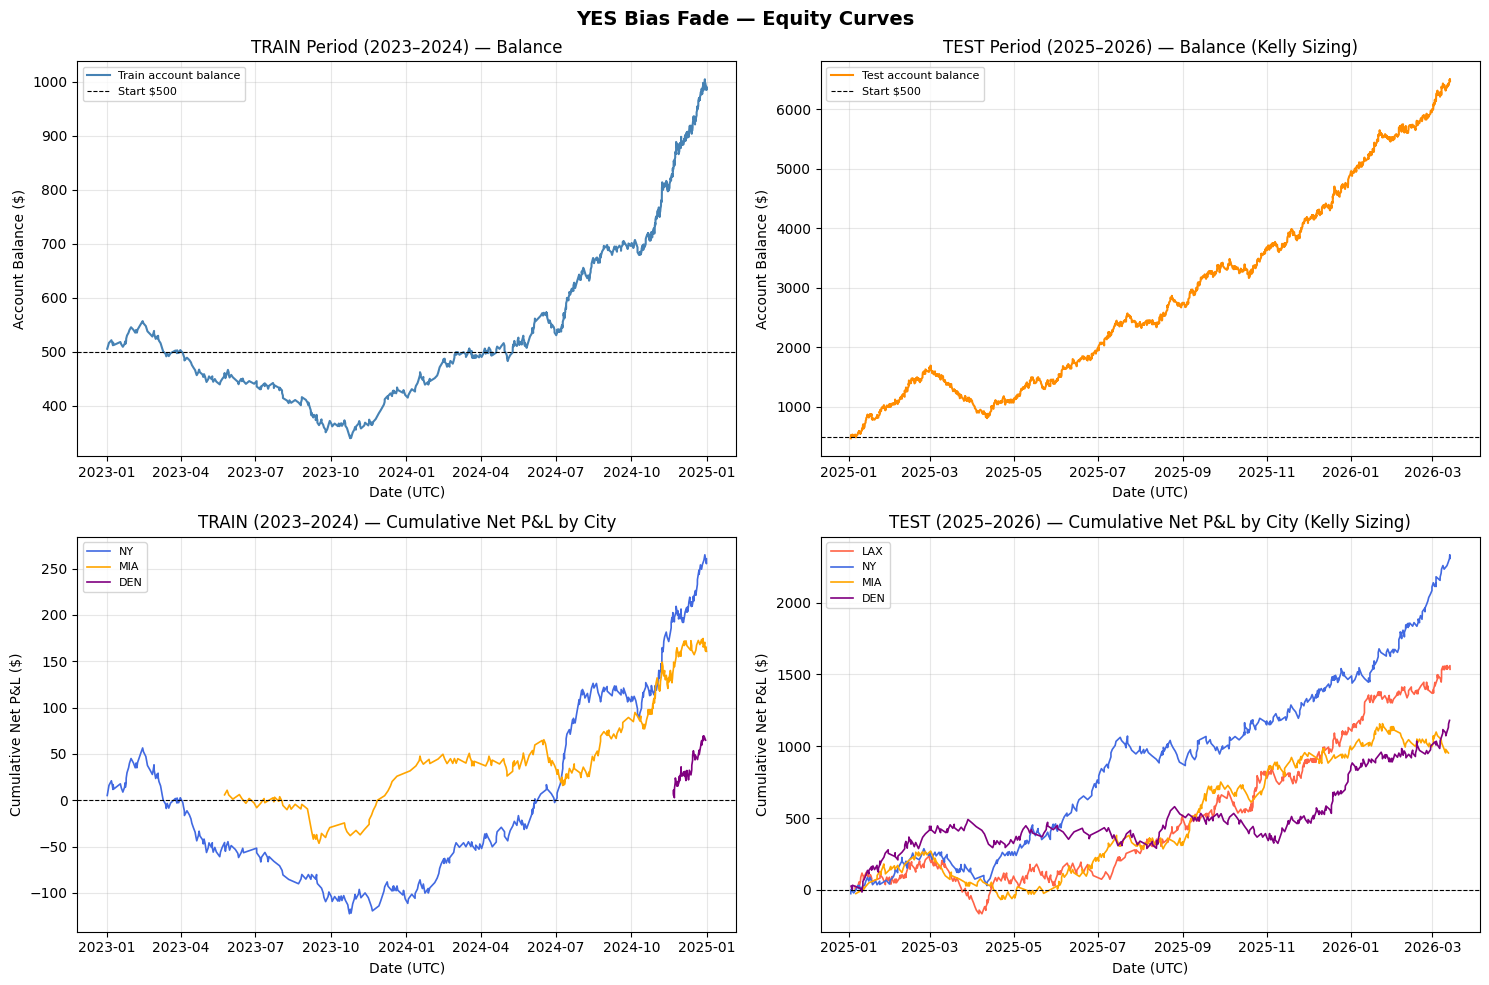

In [26]:
# Cell 9: Equity Curve Charts — Train vs Test, and Test by City

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("YES Bias Fade — Equity Curves", fontsize=14, fontweight="bold")

city_colors = {"LAX": "tomato", "NY": "royalblue", "CHI": "green", "MIA": "orange", "DEN": "purple"}

# ── (0,0) Train: cumulative net P&L ─────────────────────────────────────────────
ax = axes[0, 0]
train_exec = train_results[train_results["executed"] == True]
train_balance_curve = STARTING_BALANCE + train_exec["net_pnl"].cumsum()
ax.plot(train_exec["created_time"].values, train_balance_curve.values,
        color="steelblue", linewidth=1.5, label="Train account balance")
ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--", label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("TRAIN Period (2023–2024) — Balance")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Account Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (0,1) Test: cumulative net P&L ──────────────────────────────────────────────
ax = axes[0, 1]
test_exec = test_results[test_results["executed"] == True]
test_balance_curve = STARTING_BALANCE + test_exec["net_pnl"].cumsum()
ax.plot(test_exec["created_time"].values, test_balance_curve.values,
        color="darkorange", linewidth=1.5, label="Test account balance")
ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--", label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("TEST Period (2025–2026) — Balance (Kelly Sizing)")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Account Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,0) Train: cumulative P&L by city ─────────────────────────────────────────
ax = axes[1, 0]
for city in CITIES:
    city_df = train_exec[train_exec["city"] == city].sort_values("created_time")
    if city_df.empty:
        continue
    ax.plot(
        city_df["created_time"].values,
        city_df["net_pnl"].cumsum().values,
        label=city,
        color=city_colors.get(city, "gray"),
        linewidth=1.2,
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("TRAIN (2023–2024) — Cumulative Net P&L by City")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,1) Test: cumulative P&L by city ──────────────────────────────────────────
ax = axes[1, 1]
for city in CITIES:
    city_df = test_exec[test_exec["city"] == city].sort_values("created_time")
    if city_df.empty:
        continue
    ax.plot(
        city_df["created_time"].values,
        city_df["net_pnl"].cumsum().values,
        label=city,
        color=city_colors.get(city, "gray"),
        linewidth=1.2,
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("TEST (2025–2026) — Cumulative Net P&L by City (Kelly Sizing)")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Cell: Dynamic Fee Calculation
#
# Recalculates fees based on fill_type (maker vs taker) vs the static 7% taker-only rate.
# Uses _sim_df from the Maker Fill Simulation cell above.

import numpy as np

# Maker fee rate: 1.75%   Taker fee rate: 7.00%   Unfilled: 0%
def compute_dynamic_fee(row) -> float:
    """Compute per-contract fee based on fill type.

    Args:
        row: DataFrame row with yes_price, fill_type, unfilled, num_contracts.

    Returns:
        Total fee in dollars for this trade.
    """
    if row["unfilled"]:
        return 0.0
    yes_p = row["yes_price"]
    if row["fill_type"] in ("maker_patient", "maker_aggressive"):
        rate = 0.0175
    else:
        rate = 0.07
    fee_per_contract = np.ceil(rate * yes_p * (1 - yes_p) * 100) / 100
    return fee_per_contract * row["num_contracts"]

_sim_df["dynamic_fee"] = _sim_df.apply(compute_dynamic_fee, axis=1)

# Old always-taker fee for comparison
_sim_df["static_taker_fee"] = _sim_df.apply(
    lambda r: np.ceil(0.07 * r["yes_price"] * (1 - r["yes_price"]) * 100) / 100
              * r["num_contracts"],
    axis=1,
)

_total_dynamic = _sim_df["dynamic_fee"].sum()
_total_static  = _sim_df["static_taker_fee"].sum()
_fee_savings   = _total_static - _total_dynamic

print("=" * 60)
print("  DYNAMIC FEE CALCULATION — MAKER vs TAKER")
print("=" * 60)
print(f"  Contracts evaluated       : {int(_sim_df['num_contracts'].sum())}")
print()
print(f"  Old fee (always taker 7%) : ${_total_static:.4f}")
print(f"  New fee (dynamic rate)    : ${_total_dynamic:.4f}")
print(f"  Fee savings               : ${_fee_savings:.4f}  "
      f"({_fee_savings / _total_static * 100:.1f}% reduction)")
print()

# Per-type breakdown
for _ft in ["maker_patient", "maker_aggressive", "taker_fallback"]:
    _mask  = (_sim_df["fill_type"] == _ft) & (~_sim_df["unfilled"])
    _dyn   = _sim_df.loc[_mask, "dynamic_fee"].sum()
    _stat  = _sim_df.loc[_mask, "static_taker_fee"].sum()
    _saved = _stat - _dyn
    _n     = int(_mask.sum())
    if _n > 0:
        print(f"  {_ft:<22} : n={_n:>4} | "
              f"dynamic=${_dyn:.4f} | static=${_stat:.4f} | savings=${_saved:.4f}")

_unfill_mask = _sim_df["unfilled"]
_n_uf = int(_unfill_mask.sum())
if _n_uf > 0:
    print(f"  {'unfilled':<22} : n={_n_uf:>4} | fee=$0.0000 (no fill)")

print("=" * 60)


  DYNAMIC FEE CALCULATION â€” MAKER vs TAKER
  Contracts evaluated       : 89050

  Old fee (always taker 7%) : $1781.0000
  New fee (dynamic rate)    : $1478.0000
  Fee savings               : $303.0000  (17.0% reduction)

  maker_patient          : n= 159 | dynamic=$79.5000 | static=$159.0000 | savings=$79.5000
  maker_aggressive       : n= 281 | dynamic=$140.5000 | static=$281.0000 | savings=$140.5000
  taker_fallback         : n=1258 | dynamic=$1258.0000 | static=$1258.0000 | savings=$0.0000
  unfilled               : n=  83 | fee=$0.0000 (no fill)


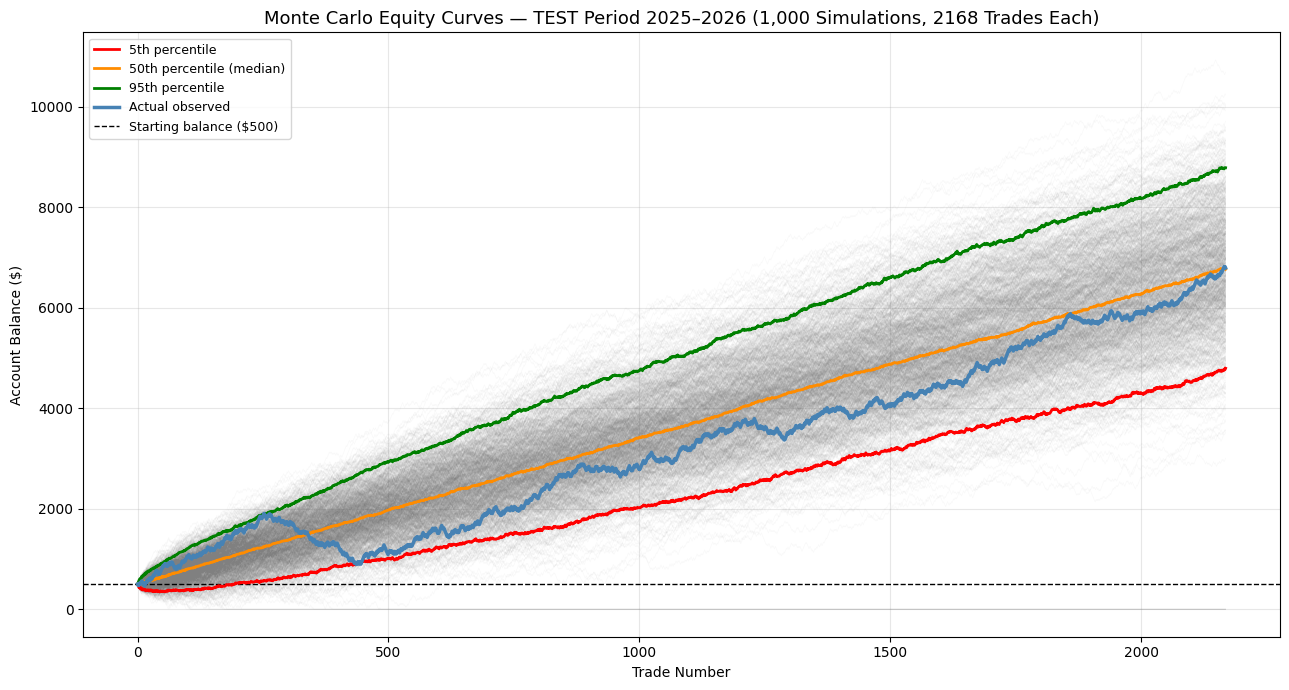

  MONTE CARLO SUMMARY â€” TEST PERIOD (2025â€“2026)
  Simulations run       : 1,000
  Trades per simulation : 2168
  % simulations ruined  : 1.1%
  Median final balance  : $6767.28
  5th pct final balance : $4797.61
  95th pct final balance: $8789.90
  Actual final balance  : $6794.02


In [9]:
# Cell 10: Monte Carlo Simulation — Test Period Trade Distribution
#
# Resample the test-period per-trade net P&L distribution 1,000 times.
# Each simulation draws (with replacement) the same number of trades as observed.
# Ruin condition applied: once balance hits 0, it stays at 0.

N_SIMS   = 1000
rng      = np.random.default_rng(seed=42)

# ── Extract per-trade P&L from executed test trades ──────────────────────────────
test_exec_pnl = test_results.loc[test_results["executed"] == True, "net_pnl"].values
n_test_trades = len(test_exec_pnl)

if n_test_trades == 0:
    print("No executed test trades — skipping Monte Carlo.")
else:
    # ── Build actual equity curve for overlay ────────────────────────────────────
    actual_curve = np.concatenate([[STARTING_BALANCE], STARTING_BALANCE + np.cumsum(test_exec_pnl)])
    actual_curve = np.maximum(actual_curve, 0.0)  # floor at 0 (ruin)

    # ── Run 1,000 simulations ────────────────────────────────────────────────────
    sim_final_balances = np.empty(N_SIMS)
    sim_curves         = np.empty((N_SIMS, n_test_trades + 1))

    for s in range(N_SIMS):
        # Resample trade P&Ls with replacement
        sampled_pnl = rng.choice(test_exec_pnl, size=n_test_trades, replace=True)

        # Build equity curve with ruin floor
        curve    = np.empty(n_test_trades + 1)
        curve[0] = STARTING_BALANCE
        ruined   = False
        for i, pnl in enumerate(sampled_pnl):
            if ruined:
                curve[i + 1] = 0.0
            else:
                new_bal = curve[i] + pnl
                if new_bal <= 0:
                    new_bal = 0.0
                    ruined  = True
                curve[i + 1] = new_bal
        sim_curves[s]         = curve
        sim_final_balances[s] = curve[-1]

    # ── Percentile paths ─────────────────────────────────────────────────────────
    p05_curve    = np.percentile(sim_curves, 5,  axis=0)
    p50_curve    = np.percentile(sim_curves, 50, axis=0)
    p95_curve    = np.percentile(sim_curves, 95, axis=0)

    pct_ruined   = (sim_final_balances == 0.0).mean() * 100
    median_final = np.median(sim_final_balances)
    p05_final    = np.percentile(sim_final_balances, 5)
    p95_final    = np.percentile(sim_final_balances, 95)

    x_axis = np.arange(n_test_trades + 1)

    # ── Plot ─────────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 7))

    # All simulation paths (light gray)
    for s in range(N_SIMS):
        ax.plot(x_axis, sim_curves[s], color="gray", alpha=0.05, linewidth=0.5)

    # Percentile paths
    ax.plot(x_axis, p05_curve, color="red",    linewidth=2.0, label="5th percentile",  zorder=4)
    ax.plot(x_axis, p50_curve, color="darkorange", linewidth=2.0, label="50th percentile (median)", zorder=4)
    ax.plot(x_axis, p95_curve, color="green",  linewidth=2.0, label="95th percentile", zorder=4)

    # Actual observed curve
    ax.plot(x_axis, actual_curve, color="steelblue", linewidth=2.5,
            label="Actual observed", zorder=5)

    # Starting balance reference
    ax.axhline(STARTING_BALANCE, color="black", linewidth=1.0, linestyle="--",
               label=f"Starting balance (${STARTING_BALANCE:.0f})", zorder=3)

    ax.set_title(
        f"Monte Carlo Equity Curves — TEST Period 2025–2026 ({N_SIMS:,} Simulations, {n_test_trades} Trades Each)",
        fontsize=13,
    )
    ax.set_xlabel("Trade Number")
    ax.set_ylabel("Account Balance ($)")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Monte Carlo Summary ───────────────────────────────────────────────────────
    print("=" * 55)
    print("  MONTE CARLO SUMMARY — TEST PERIOD (2025–2026)")
    print("=" * 55)
    print(f"  Simulations run       : {N_SIMS:,}")
    print(f"  Trades per simulation : {n_test_trades}")
    print(f"  % simulations ruined  : {pct_ruined:.1f}%")
    print(f"  Median final balance  : ${median_final:.2f}")
    print(f"  5th pct final balance : ${p05_final:.2f}")
    print(f"  95th pct final balance: ${p95_final:.2f}")
    print(f"  Actual final balance  : ${actual_curve[-1]:.2f}")
    print("=" * 55)

In [28]:
# Cell: Unfill Risk Metrics
#
# Quantifies the opportunity cost of signals that did not fill under maker escalation.
# Uses _sim_df from the Maker Fill Simulation cell.

import numpy as np

_exec_sim = _sim_df.copy()

# ── Counts ────────────────────────────────────────────────────────────────────
_n_signals  = len(_exec_sim)
_n_filled   = int((~_exec_sim["unfilled"]).sum())
_n_unfilled = int(_exec_sim["unfilled"].sum())
_unfill_rate = _n_unfilled / _n_signals if _n_signals > 0 else float("nan")

# ── Unfilled by city ──────────────────────────────────────────────────────────
_unfilled_by_city = (
    _exec_sim[_exec_sim["unfilled"]]
    .groupby("city")
    .size()
    .rename("unfilled_count")
    .sort_values(ascending=False)
)

# ── Unfilled by YES price bucket ──────────────────────────────────────────────
_price_bins   = [0.55, 0.58, 0.61, 0.64, 0.651]
_price_labels = ["0.55-0.57", "0.58-0.60", "0.61-0.63", "0.64-0.65"]
_exec_sim["price_bucket"] = pd.cut(
    _exec_sim["yes_price"],
    bins=_price_bins,
    labels=_price_labels,
    right=False,
    include_lowest=True,
)
_unfilled_by_bucket = (
    _exec_sim[_exec_sim["unfilled"]]
    .groupby("price_bucket", observed=True)
    .size()
    .rename("unfilled_count")
)

# ── Missed P&L (theoretical profit on unfilled trades) ────────────────────────
# Theoretical gross profit per trade = (1 - actual_entry_no) * num_contracts if no_won,
# else -actual_entry_no * num_contracts.
_uf_df = _exec_sim[_exec_sim["unfilled"]].copy()
_uf_df["theoretical_gross"] = _uf_df.apply(
    lambda r: (1.0 - r["actual_entry_no"]) * r["num_contracts"] if r["no_won"]
              else -r["actual_entry_no"] * r["num_contracts"],
    axis=1,
)
_missed_pnl = _uf_df["theoretical_gross"].sum()

# ── Display ────────────────────────────────────────────────────────────────────
_sep = "=" * 60
print(_sep)
print("  UNFILL RISK METRICS — TEST PERIOD")
print(_sep)
print(f"  Total signals fired    : {_n_signals}")
print(f"  Total filled trades    : {_n_filled}  ({_n_filled/_n_signals:.1%})")
print(f"  Total unfilled count   : {_n_unfilled}  ({_unfill_rate:.1%})")
print()
print("  Unfilled by city:")
if _unfilled_by_city.empty:
    print("    (none)")
else:
    for _city, _cnt in _unfilled_by_city.items():
        print(f"    {_city:<6}: {int(_cnt)}")
print()
print("  Unfilled by YES price bucket:")
for _bucket in _price_labels:
    _cnt = int(_unfilled_by_bucket.get(_bucket, 0))
    print(f"    {_bucket}: {_cnt}")
print()
print(f"  Missed P&L (left on table): ${_missed_pnl:.4f}")
print(f"  (theoretical gross P&L on unfilled trades — hold-to-settlement)")
print(_sep)


  UNFILL RISK METRICS â€” TEST PERIOD
  Total signals fired    : 1781
  Total filled trades    : 1698  (95.3%)
  Total unfilled count   : 83  (4.7%)

  Unfilled by city:
    NY    : 25
    DEN   : 23
    LAX   : 22
    MIA   : 13

  Unfilled by YES price bucket:
    0.55-0.57: 16
    0.58-0.60: 19
    0.61-0.63: 22
    0.64-0.65: 26

  Missed P&L (left on table): $818.5000
  (theoretical gross P&L on unfilled trades â€” hold-to-settlement)


In [10]:
# Cell 11: Save Trade Logs — Train and Test Separately

display_cols = [
    "created_time", "city", "ticker",
    "yes_price", "no_price_raw", "actual_entry_no",
    "num_contracts", "executed", "skip_reason",
    "settlement_value", "no_won",
    "gross_pnl", "entry_fee", "net_pnl",
    "balance_before", "balance_after",
]

# Filter to columns that exist in the results
train_display_cols = [c for c in display_cols if c in train_results.columns]
test_display_cols  = [c for c in display_cols if c in test_results.columns]

# ── Save train log ───────────────────────────────────────────────────────────────
train_out = DATA_DIR / "yes_bias_fade_train_trades.csv"
train_results[train_display_cols].to_csv(train_out, index=False)
print(f"Train trade log saved : {train_out}  ({len(train_results)} rows)")

# ── Save test log ────────────────────────────────────────────────────────────────
test_out = DATA_DIR / "yes_bias_fade_test_trades.csv"
test_results[test_display_cols].to_csv(test_out, index=False)
print(f"Test trade log saved  : {test_out}  ({len(test_results)} rows)")

# ── Quick display of first 30 test trades ────────────────────────────────────────
print(f"\nFirst 30 executed TEST trades:")
test_exec_display = test_results[test_results["executed"] == True][test_display_cols].head(30)
print(test_exec_display.to_string(index=False))

Train trade log saved : C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data\yes_bias_fade_train_trades.csv  (1258 rows)
Test trade log saved  : C:\Users\ethan\Downloads\Kalshitrading\LIVE\backtest_data\yes_bias_fade_test_trades.csv  (2168 rows)

First 30 executed TEST trades:
                    created_time city                  ticker  yes_price  no_price_raw  actual_entry_no  num_contracts  executed skip_reason  settlement_value  no_won  gross_pnl  entry_fee  net_pnl  balance_before  balance_after
2025-01-02 13:00:25.586615+00:00   NY  KXHIGHNY-25JAN02-B42.5       0.55          0.45             0.49             49      True        None               1.0   False     -24.01       0.98   -24.99          500.00         475.01
2025-01-02 16:10:41.314679+00:00   NY    KXHIGHNY-25JAN02-T43       0.65          0.35             0.39             50      True        None               0.0    True      30.50       1.00    29.50          475.01         504.51
2025-01-02 16:24:32.600763+00:

In [11]:
# Cell 12: Slippage Sensitivity Analysis
#
# Re-run train+test at 5¢ and 7¢ slippage, re-deriving Kelly from train at each level.
# The 4¢ baseline already run is included for comparison.
# All sensitivity runs suppress verbose backtest prints via contextlib.redirect_stdout.

import contextlib
import io as _io_slip

_SLIPPAGE_LEVELS = [0.04, 0.05, 0.07]   # dollars; 4¢ is the established baseline

_sensitivity_rows = []

for _slip in _SLIPPAGE_LEVELS:
    _slip_label = f"{int(_slip * 100)}¢"

    # ── TRAIN run at this slippage level ──────────────────────────────────────
    _buf = _io_slip.StringIO()
    with contextlib.redirect_stdout(_buf):
        _tr = run_backtest(
            signals          = train_signals,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = TRAIN_CONTRACTS,
            kelly_fraction   = None,
            kelly_win_rate   = None,
            kelly_b          = None,
            slippage         = _slip,
            period_label     = "",
        )

    _tr_exec = _tr[_tr["executed"] == True]
    _tr_n    = len(_tr_exec)
    _tr_wr   = _tr_exec["no_won"].mean() if _tr_n > 0 else float("nan")
    _tr_pnl  = _tr_exec["net_pnl"].sum()
    _tr_roc  = _tr_pnl / STARTING_BALANCE * 100
    _tr_wins = _tr_exec.loc[_tr_exec["net_pnl"] > 0, "net_pnl"]
    _tr_loss = _tr_exec.loc[_tr_exec["net_pnl"] < 0, "net_pnl"]
    _tr_pf   = (_tr_wins.sum() / abs(_tr_loss.sum())) if len(_tr_loss) > 0 and abs(_tr_loss.sum()) > 0 else float("nan")
    _tr_edge = _tr_exec["net_pnl"].mean() if _tr_n > 0 else float("nan")

    _sensitivity_rows.append({
        "Slippage": _slip_label,
        "Period":   "TRAIN",
        "Trades":   _tr_n,
        "Win Rate": _tr_wr,
        "Net P&L":  _tr_pnl,
        "ROC%":     _tr_roc,
        "Profit Factor": _tr_pf,
        "Avg Edge/Trade": _tr_edge,
    })

    # ── Derive Kelly from this train run ──────────────────────────────────────
    _s_wins      = _tr_exec[_tr_exec["no_won"] == True]["net_pnl"]
    _s_losses    = _tr_exec[_tr_exec["no_won"] == False]["net_pnl"]
    _s_win_rate  = _tr_exec["no_won"].mean() if _tr_n > 0 else 0.5
    _s_avg_win   = _s_wins.mean()        if len(_s_wins)   > 0 else 0.0
    _s_avg_loss  = abs(_s_losses.mean()) if len(_s_losses) > 0 else 1e-9
    _s_kelly_b   = _s_avg_win / _s_avg_loss

    # ── TEST run at this slippage level with derived Kelly ────────────────────
    _buf2 = _io_slip.StringIO()
    with contextlib.redirect_stdout(_buf2):
        _te = run_backtest(
            signals          = test_signals,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = None,
            kelly_fraction   = KELLY_FRACTION,
            kelly_win_rate   = _s_win_rate,
            kelly_b          = _s_kelly_b,
            slippage         = _slip,
            period_label     = "",
        )

    _te_exec = _te[_te["executed"] == True]
    _te_n    = len(_te_exec)
    _te_wr   = _te_exec["no_won"].mean() if _te_n > 0 else float("nan")
    _te_pnl  = _te_exec["net_pnl"].sum()
    _te_roc  = _te_pnl / STARTING_BALANCE * 100
    _te_wins = _te_exec.loc[_te_exec["net_pnl"] > 0, "net_pnl"]
    _te_loss = _te_exec.loc[_te_exec["net_pnl"] < 0, "net_pnl"]
    _te_pf   = (_te_wins.sum() / abs(_te_loss.sum())) if len(_te_loss) > 0 and abs(_te_loss.sum()) > 0 else float("nan")
    _te_edge = _te_exec["net_pnl"].mean() if _te_n > 0 else float("nan")

    _sensitivity_rows.append({
        "Slippage": _slip_label,
        "Period":   "TEST",
        "Trades":   _te_n,
        "Win Rate": _te_wr,
        "Net P&L":  _te_pnl,
        "ROC%":     _te_roc,
        "Profit Factor": _te_pf,
        "Avg Edge/Trade": _te_edge,
    })

# ── Full comparison table ──────────────────────────────────────────────────────
_sens_df = pd.DataFrame(_sensitivity_rows)

# Format for display
_disp = _sens_df.copy()
_disp["Win Rate"]       = _disp["Win Rate"].map("{:.2%}".format)
_disp["Net P&L"]        = _disp["Net P&L"].map("${:.2f}".format)
_disp["ROC%"]           = _disp["ROC%"].map("{:.1f}%".format)
_disp["Profit Factor"]  = _disp["Profit Factor"].map("{:.4f}".format)
_disp["Avg Edge/Trade"] = _disp["Avg Edge/Trade"].map("${:.4f}".format)

print("=" * 90)
print("  SLIPPAGE SENSITIVITY — ALL PERIODS")
print("=" * 90)
print(_disp.rename(columns={"Trades": "Trades Executed"}).to_string(index=False))
print()

# ── TEST-only comparison table ────────────────────────────────────────────────
_test_only = _sens_df[_sens_df["Period"] == "TEST"].copy()
_to_disp   = _test_only.copy()
_to_disp["Win Rate"]       = _to_disp["Win Rate"].map("{:.2%}".format)
_to_disp["Net P&L"]        = _to_disp["Net P&L"].map("${:.2f}".format)
_to_disp["ROC%"]           = _to_disp["ROC%"].map("{:.1f}%".format)
_to_disp["Profit Factor"]  = _to_disp["Profit Factor"].map("{:.4f}".format)
_to_disp["Avg Edge/Trade"] = _to_disp["Avg Edge/Trade"].map("${:.4f}".format)

print("=" * 90)
print("  SLIPPAGE SENSITIVITY — TEST PERIOD ONLY (side-by-side)")
print("=" * 90)
print(_to_disp.drop(columns=["Period"]).rename(columns={"Trades": "Trades Executed"}).to_string(index=False))
print()
print("Note: 4¢ baseline replicates the Cell 7/8 result (Kelly re-derived consistently).")
print("      Higher slippage reduces avg edge and profit factor — check for sign flip.")

  SLIPPAGE SENSITIVITY â€” ALL PERIODS
Slippage Period  Trades Executed Win Rate  Net P&L    ROC% Profit Factor Avg Edge/Trade
      4Â¢  TRAIN             1258   52.94%  $636.90  127.4%        1.2245        $0.5063
      4Â¢   TEST             2168   54.38% $6294.02 1258.8%        1.2606        $2.9031
      5Â¢  TRAIN             1258   52.94%  $511.10  102.2%        1.1764        $0.4063
      5Â¢   TEST             2168   54.38% $5198.39 1039.7%        1.2112        $2.3978
      7Â¢  TRAIN             1258   52.94%  $259.50   51.9%        1.0861        $0.2063
      7Â¢   TEST             2168   54.38% $2620.49  524.1%        1.1276        $1.2087

  SLIPPAGE SENSITIVITY â€” TEST PERIOD ONLY (side-by-side)
Slippage  Trades Executed Win Rate  Net P&L    ROC% Profit Factor Avg Edge/Trade
      4Â¢             2168   54.38% $6294.02 1258.8%        1.2606        $2.9031
      5Â¢             2168   54.38% $5198.39 1039.7%        1.2112        $2.3978
      7Â¢             2168   54.38

In [12]:
# Cell 13: Statistical Significance Tests
#
# Test whether the observed win rates and per-trade P&L are statistically distinguishable
# from chance using binomial test, t-test, and z-test.

try:
    import scipy.stats as stats
except ImportError:
    raise ImportError("scipy is required: pip install scipy")

import math as _math


def run_significance_tests(results_df: pd.DataFrame, period_label: str) -> None:
    """Run binomial test, one-sample t-test, and z-test on win rate for a backtest period.

    Parameters
    ----------
    results_df   : DataFrame returned by run_backtest()
    period_label : string label for display headers
    """
    exec_df = results_df[results_df["executed"] == True].copy()

    if exec_df.empty:
        print(f"{period_label}: no executed trades — skipping significance tests.")
        return

    n_trades   = len(exec_df)
    n_wins     = int(exec_df["no_won"].sum())
    n_losses   = n_trades - n_wins
    win_rate   = n_wins / n_trades
    net_pnl_arr = exec_df["net_pnl"].values

    sep = "=" * 65
    print(sep)
    print(f"  STATISTICAL SIGNIFICANCE — {period_label}")
    print(sep)
    print(f"  Trades: {n_trades}  |  Wins: {n_wins}  |  Losses: {n_losses}  |  Win Rate: {win_rate:.4f}")
    print()

    # ── Test 1: Binomial test (one-sided, H1: win_rate > 0.5) ─────────────────
    binom_result = stats.binomtest(k=n_wins, n=n_trades, p=0.5, alternative="greater")
    binom_pval   = binom_result.pvalue
    binom_sig    = binom_pval < 0.05

    print(f"  [1] BINOMIAL TEST  (H0: p=0.5, H1: p>0.5, one-sided)")
    print(f"      Observed win rate : {win_rate:.4f}")
    print(f"      n_wins / n_trades  : {n_wins} / {n_trades}")
    print(f"      p-value            : {binom_pval:.6f}")
    verdict_b = "SIGNIFICANT at alpha=0.05" if binom_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_b}")
    print()

    # ── Test 2: One-sample t-test on per-trade net P&L vs zero ────────────────
    t_stat, t_pval_two = stats.ttest_1samp(net_pnl_arr, 0.0, alternative="greater")
    mean_pnl = net_pnl_arr.mean()
    se_pnl   = net_pnl_arr.std(ddof=1) / _math.sqrt(n_trades)
    # 95% CI lower bound (one-sided lower for greater alternative)
    t_crit_95 = stats.t.ppf(0.05, df=n_trades - 1)  # 5th pct of t
    ci_low    = mean_pnl + t_crit_95 * se_pnl        # conservative lower bound
    ci_high   = float("inf")
    ttest_sig = t_pval_two < 0.05

    print(f"  [2] ONE-SAMPLE T-TEST  (H0: mean_pnl=0, H1: mean_pnl>0, one-sided)")
    print(f"      Mean P&L / trade   : ${mean_pnl:.4f}")
    print(f"      t-statistic        : {t_stat:.4f}")
    print(f"      p-value            : {t_pval_two:.6f}")
    print(f"      95% CI lower bound : ${ci_low:.4f}  (upper: +inf)")
    verdict_t = "SIGNIFICANT at alpha=0.05" if ttest_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_t}")
    print()

    # ── Test 3: Z-test on win rate (manual) ───────────────────────────────────
    z_score = (win_rate - 0.5) / _math.sqrt(0.25 / n_trades)
    z_pval  = 1.0 - stats.norm.cdf(z_score)   # one-sided upper tail
    z_sig   = z_pval < 0.05

    print(f"  [3] Z-TEST ON WIN RATE  (H0: p=0.5, H1: p>0.5, one-sided)")
    print(f"      Z-score            : {z_score:.4f}")
    print(f"      p-value            : {z_pval:.6f}")
    verdict_z = "SIGNIFICANT at alpha=0.05" if z_sig else "NOT significant at alpha=0.05"
    print(f"      Verdict            : {verdict_z}")
    print()

    # ── Test 4: Minimum trades for 80% power at observed effect size ──────────
    p_obs  = win_rate
    delta  = p_obs - 0.5
    if delta > 0:
        z_alpha = stats.norm.ppf(0.95)   # one-sided alpha=0.05
        z_beta  = stats.norm.ppf(0.80)   # 80% power
        n_needed = ((z_alpha + z_beta) ** 2 * 0.25) / (delta ** 2)
        print(f"  [4] MINIMUM TRADES FOR 80% POWER (informational)")
        print(f"      Observed effect (p - 0.5): {delta:.4f}")
        print(f"      Trades needed (80% power) : {int(_math.ceil(n_needed))}")
        print(f"      Trades available          : {n_trades}")
        powered = "Adequately powered" if n_trades >= n_needed else "UNDERPOWERED"
        print(f"      Assessment                : {powered}")
    else:
        print(f"  [4] Effect size is zero or negative — power analysis not meaningful.")
    print()
    print(sep)
    print()


# ── Run tests on TEST period ───────────────────────────────────────────────────
run_significance_tests(test_results, "TEST (2025–2026)")

# ── Run tests on TRAIN period for comparison ───────────────────────────────────
run_significance_tests(train_results, "TRAIN (2023–2024)")

  STATISTICAL SIGNIFICANCE â€” TEST (2025â€“2026)
  Trades: 2168  |  Wins: 1179  |  Losses: 989  |  Win Rate: 0.5438

  [1] BINOMIAL TEST  (H0: p=0.5, H1: p>0.5, one-sided)
      Observed win rate : 0.5438
      n_wins / n_trades  : 1179 / 2168
      p-value            : 0.000024
      Verdict            : SIGNIFICANT at alpha=0.05

  [2] ONE-SAMPLE T-TEST  (H0: mean_pnl=0, H1: mean_pnl>0, one-sided)
      Mean P&L / trade   : $2.9031
      t-statistic        : 5.3918
      p-value            : 0.000000
      95% CI lower bound : $2.0171  (upper: +inf)
      Verdict            : SIGNIFICANT at alpha=0.05

  [3] Z-TEST ON WIN RATE  (H0: p=0.5, H1: p>0.5, one-sided)
      Z-score            : 4.0806
      p-value            : 0.000022
      Verdict            : SIGNIFICANT at alpha=0.05

  [4] MINIMUM TRADES FOR 80% POWER (informational)
      Observed effect (p - 0.5): 0.0438
      Trades needed (80% power) : 805
      Trades available          : 2168
      Assessment                : A

All signals (no dedup) â€” train: 32157,  test: 250916
Baseline dedup signals â€” train: 1258,  test: 2168
Avg signals per ticker (test) : 115.74

Running 500 partial-fill Monte Carlo simulations...
Done.

  PARTIAL FILL SIMULATION SUMMARY (TEST Period, 500 iters)
  Metric                         Baseline (full fill)  Partial fill median
  ------------------------------ -------------------- --------------------
  Trades executed                                2168               4203.0
  Net P&L ($)                                 6294.02              2756.28
  Win rate                                     54.38%               49.73%

  Partial fill 5th pct Net P&L  : $2201.06
  Partial fill 95th pct Net P&L : $3241.00
  % simulations ending in ruin  : 0.0%


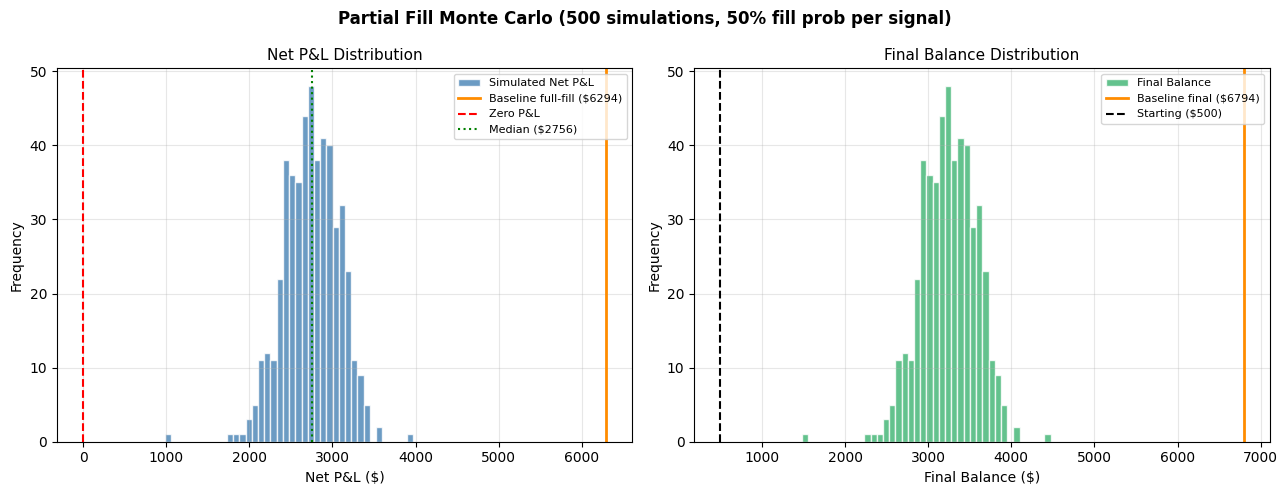

In [13]:
# Cell 14: Partial Fill Simulation
#
# Simulate 50% independent fill probability per qualifying signal.
# Each ticker may have multiple qualifying trades per day; we attempt fills sequentially
# until one succeeds or all are exhausted.

import contextlib
import io as _io

# ── Step 1: Build "all signals" DataFrame (no dedup on ticker) ─────────────────
def build_all_signals_df() -> pd.DataFrame:
    """Same as build_signal_df() from Cell 4 but skips drop_duplicates.
    Returns ALL qualifying signal rows, sorted by created_time."""
    signal_rows = []
    for city, prefix in CITIES.items():
        trades  = trades_dfs[city].copy()
        markets = markets_dfs[city][["ticker", "settlement_value", "yes_won", "close_time"]].copy()

        mask = (
            (trades["yes_price_dollars"] >= YES_LOW) &
            (trades["yes_price_dollars"] <= YES_HIGH) &
            (trades["taker_side"].str.lower() == "yes")
        )
        signals = trades[mask].copy()
        if signals.empty:
            continue

        signals["market_date"] = signals["ticker"].str.extract(DATE_RE)
        signals = signals.sort_values("created_time")
        # NOTE: intentionally NO drop_duplicates here

        merged = signals.merge(markets, on="ticker", how="left")
        merged = merged.dropna(subset=["settlement_value"])
        if merged.empty:
            continue

        merged["no_won"] = ~merged["yes_won"]
        merged["city"]   = city
        signal_rows.append(merged)

    if not signal_rows:
        return pd.DataFrame()

    df = pd.concat(signal_rows, ignore_index=True)
    df = df.sort_values("created_time").reset_index(drop=True)
    return df


all_signals_full = build_all_signals_df()

# Apply train/test date split
train_all_signals = all_signals_full[
    (all_signals_full["created_time"] >= TRAIN_START) &
    (all_signals_full["created_time"] <  TRAIN_CUTOFF)
].copy().reset_index(drop=True)

test_all_signals = all_signals_full[
    all_signals_full["created_time"] >= TRAIN_CUTOFF
].copy().reset_index(drop=True)

print(f"All signals (no dedup) — train: {len(train_all_signals)},  test: {len(test_all_signals)}")
print(f"Baseline dedup signals — train: {len(train_signals)},  test: {len(test_signals)}")
print(f"Avg signals per ticker (test) : {len(test_all_signals) / max(len(test_signals), 1):.2f}")


# ── Step 2: Simulate fills with 50% independent fill probability ───────────────
def simulate_fills(all_signals_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    """For each ticker, iterate through qualifying signals sorted by created_time.
    Each signal: draw uniform(0,1); if < 0.5 fill it and stop; else miss it and try next.

    Parameters
    ----------
    all_signals_df : DataFrame of all qualifying signals (multiple rows per ticker allowed)
    seed           : RNG seed for reproducibility

    Returns
    -------
    DataFrame of filled signals (at most one per ticker), sorted by created_time.
    """
    if all_signals_df.empty:
        return pd.DataFrame()

    rng_fill  = np.random.default_rng(seed)
    filled_rows = []

    for ticker, group in all_signals_df.groupby("ticker"):
        group_sorted = group.sort_values("created_time")
        for _, row in group_sorted.iterrows():
            if rng_fill.uniform() < 0.5:
                filled_rows.append(row)
                break  # filled — move to next ticker
        # if no row was filled for this ticker, it is simply skipped

    if not filled_rows:
        return pd.DataFrame()

    result = pd.DataFrame(filled_rows).sort_values("created_time").reset_index(drop=True)
    return result


# ── Step 3: 500 Monte Carlo iterations on TEST partial fills ───────────────────
N_PARTIAL_SIMS = 500
partial_results = {
    "n_trades":    np.empty(N_PARTIAL_SIMS),
    "net_pnl":     np.empty(N_PARTIAL_SIMS),
    "win_rate":    np.empty(N_PARTIAL_SIMS),
    "final_bal":   np.empty(N_PARTIAL_SIMS),
}

_null_sink = _io.StringIO()

print(f"\nRunning {N_PARTIAL_SIMS} partial-fill Monte Carlo simulations...")

for _i in range(N_PARTIAL_SIMS):
    filled_df = simulate_fills(test_all_signals, seed=_i)

    if filled_df.empty:
        partial_results["n_trades"][_i]  = 0
        partial_results["net_pnl"][_i]   = 0.0
        partial_results["win_rate"][_i]  = float("nan")
        partial_results["final_bal"][_i] = STARTING_BALANCE
        continue

    with contextlib.redirect_stdout(_null_sink):
        _bt = run_backtest(
            signals          = filled_df,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = None,
            kelly_fraction   = KELLY_FRACTION,
            kelly_win_rate   = train_win_rate,
            kelly_b          = kelly_b,
            slippage         = SLIPPAGE_CENTS,
            period_label     = "",
        )

    _exec = _bt[_bt["executed"] == True]
    partial_results["n_trades"][_i]  = len(_exec)
    partial_results["net_pnl"][_i]   = _exec["net_pnl"].sum() if len(_exec) > 0 else 0.0
    partial_results["win_rate"][_i]  = _exec["no_won"].mean() if len(_exec) > 0 else float("nan")
    partial_results["final_bal"][_i] = _bt["balance_after"].iloc[-1] if len(_bt) > 0 else STARTING_BALANCE

print("Done.")

# ── Step 4: Summary comparison ─────────────────────────────────────────────────
baseline_exec    = test_results[test_results["executed"] == True]
baseline_trades  = len(baseline_exec)
baseline_pnl     = baseline_exec["net_pnl"].sum()
baseline_wr      = baseline_exec["no_won"].mean()

med_trades  = np.nanmedian(partial_results["n_trades"])
med_pnl     = np.nanmedian(partial_results["net_pnl"])
med_wr      = np.nanmedian(partial_results["win_rate"])
p05_pnl     = np.nanpercentile(partial_results["net_pnl"], 5)
p95_pnl     = np.nanpercentile(partial_results["net_pnl"], 95)
pct_ruin    = (partial_results["final_bal"] <= 0).mean() * 100

print("\n" + "=" * 60)
print("  PARTIAL FILL SIMULATION SUMMARY (TEST Period, 500 iters)")
print("=" * 60)
print(f"  {'Metric':<30} {'Baseline (full fill)':>20} {'Partial fill median':>20}")
print(f"  {'-'*30} {'-'*20} {'-'*20}")
print(f"  {'Trades executed':<30} {baseline_trades:>20} {med_trades:>20.1f}")
print(f"  {'Net P&L ($)':<30} {baseline_pnl:>20.2f} {med_pnl:>20.2f}")
print(f"  {'Win rate':<30} {baseline_wr:>20.2%} {med_wr:>20.2%}")
print(f"\n  Partial fill 5th pct Net P&L  : ${p05_pnl:.2f}")
print(f"  Partial fill 95th pct Net P&L : ${p95_pnl:.2f}")
print(f"  % simulations ending in ruin  : {pct_ruin:.1f}%")
print("=" * 60)

# ── Step 5: Plot distributions ─────────────────────────────────────────────────
fig, (ax_pnl, ax_bal) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Partial Fill Monte Carlo ({N_PARTIAL_SIMS} simulations, 50% fill prob per signal)",
    fontsize=12, fontweight="bold",
)

# Left panel: Net P&L histogram
ax_pnl.hist(partial_results["net_pnl"], bins=40, color="steelblue",
            edgecolor="white", alpha=0.8, label="Simulated Net P&L")
ax_pnl.axvline(baseline_pnl, color="darkorange", linewidth=2.0,
               label=f"Baseline full-fill (${baseline_pnl:.0f})")
ax_pnl.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero P&L")
ax_pnl.axvline(med_pnl, color="green", linewidth=1.5, linestyle=":",
               label=f"Median (${med_pnl:.0f})")
ax_pnl.set_xlabel("Net P&L ($)", fontsize=10)
ax_pnl.set_ylabel("Frequency", fontsize=10)
ax_pnl.set_title("Net P&L Distribution", fontsize=11)
ax_pnl.legend(fontsize=8)
ax_pnl.grid(True, alpha=0.3)

# Right panel: Final balance histogram
ax_bal.hist(partial_results["final_bal"], bins=40, color="mediumseagreen",
            edgecolor="white", alpha=0.8, label="Final Balance")
ax_bal.axvline(STARTING_BALANCE + baseline_pnl, color="darkorange", linewidth=2.0,
               label=f"Baseline final (${STARTING_BALANCE + baseline_pnl:.0f})")
ax_bal.axvline(STARTING_BALANCE, color="black", linewidth=1.5, linestyle="--",
               label=f"Starting (${STARTING_BALANCE:.0f})")
ax_bal.set_xlabel("Final Balance ($)", fontsize=10)
ax_bal.set_ylabel("Frequency", fontsize=10)
ax_bal.set_title("Final Balance Distribution", fontsize=11)
ax_bal.legend(fontsize=8)
ax_bal.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

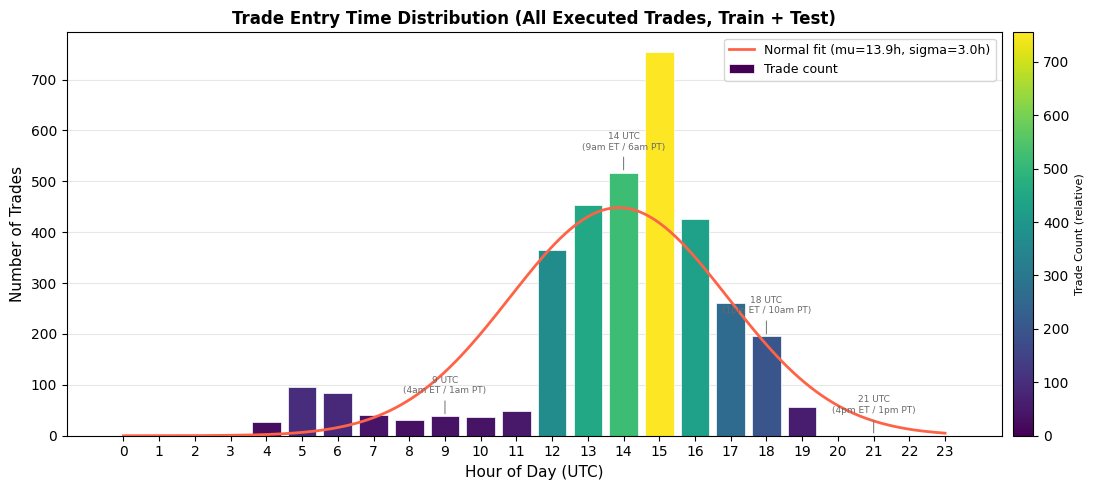


Top 5 busiest hours:
 Hour (UTC)  Trades Win Rate
         15     755    58.3%
         14     517    51.8%
         13     453    53.6%
         16     425    52.0%
         12     365    53.4%

Total executed trades analyzed: 3426
  Train: 1258  |  Test: 2168
Normal fit: mean hour = 13.87 UTC, std = 3.05 hours


In [14]:
# Cell 15: Time-of-Day Distribution
#
# Visualize when contracts are being bought across ALL executed trades (train + test combined).

import scipy.stats as _stats_tod

# ── Combine all executed trades from both periods ──────────────────────────────
train_exec_tod = train_results[train_results["executed"] == True].copy()
test_exec_tod  = test_results[test_results["executed"] == True].copy()
all_exec_tod   = pd.concat([train_exec_tod, test_exec_tod], ignore_index=True)

if all_exec_tod.empty:
    print("No executed trades found — skipping time-of-day analysis.")
else:
    # ── Extract hour of day (UTC) ──────────────────────────────────────────────
    all_exec_tod["hour_utc"] = all_exec_tod["created_time"].dt.hour

    # ── Count trades per hour ──────────────────────────────────────────────────
    hour_counts = all_exec_tod.groupby("hour_utc").size().reindex(range(24), fill_value=0)

    # ── Win rate per hour ──────────────────────────────────────────────────────
    hour_wins = all_exec_tod.groupby("hour_utc")["no_won"].agg(["sum", "count"])
    hour_wins = hour_wins.reindex(range(24), fill_value=0)
    hour_wins["win_rate"] = hour_wins.apply(
        lambda r: r["sum"] / r["count"] if r["count"] > 0 else float("nan"), axis=1
    )

    # ── Fit normal distribution to raw hour values ─────────────────────────────
    raw_hours = all_exec_tod["hour_utc"].values
    mu_fit, sigma_fit = _stats_tod.norm.fit(raw_hours)
    x_smooth  = np.linspace(0, 23, 300)
    pdf_vals  = _stats_tod.norm.pdf(x_smooth, mu_fit, sigma_fit)
    # Scale PDF to match bar heights (area of bars = total trades * bar_width=1)
    pdf_scaled = pdf_vals * len(raw_hours) * 1.0   # bar width = 1

    # ── Colormap for bars ──────────────────────────────────────────────────────
    norm_counts = hour_counts.values / max(hour_counts.values)
    cmap        = plt.cm.viridis
    bar_colors  = [cmap(v) for v in norm_counts]

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    bars = ax.bar(hour_counts.index, hour_counts.values, color=bar_colors,
                  edgecolor="white", linewidth=0.5, zorder=2, label="Trade count")

    # Normal curve overlay
    ax.plot(x_smooth, pdf_scaled, color="tomato", linewidth=2.0, zorder=3,
            label=f"Normal fit (mu={mu_fit:.1f}h, sigma={sigma_fit:.1f}h)")

    # Timezone annotations at key hours
    tz_annotations = {
        9:  "9 UTC\n(4am ET / 1am PT)",
        14: "14 UTC\n(9am ET / 6am PT)",
        18: "18 UTC\n(1pm ET / 10am PT)",
        21: "21 UTC\n(4pm ET / 1pm PT)",
    }
    for h, label_txt in tz_annotations.items():
        if h in hour_counts.index:
            ax.annotate(
                label_txt,
                xy=(h, hour_counts[h]),
                xytext=(h, hour_counts[h] + max(hour_counts.values) * 0.06),
                fontsize=6.5,
                ha="center",
                color="dimgray",
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
            )

    ax.set_xlabel("Hour of Day (UTC)", fontsize=11)
    ax.set_ylabel("Number of Trades", fontsize=11)
    ax.set_title(
        "Trade Entry Time Distribution (All Executed Trades, Train + Test)",
        fontsize=12, fontweight="bold",
    )
    ax.set_xticks(range(24))
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, hour_counts.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("Trade Count (relative)", fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── Top 5 busiest hours table ──────────────────────────────────────────────
    print("\nTop 5 busiest hours:")
    top5_hours = hour_counts.nlargest(5).index.tolist()
    top5_df = pd.DataFrame({
        "Hour (UTC)": top5_hours,
        "Trades":     [hour_counts[h] for h in top5_hours],
        "Win Rate":   [f"{hour_wins.loc[h, 'win_rate']:.1%}" if h in hour_wins.index else "N/A"
                       for h in top5_hours],
    })
    print(top5_df.to_string(index=False))

    print(f"\nTotal executed trades analyzed: {len(all_exec_tod)}")
    print(f"  Train: {len(train_exec_tod)}  |  Test: {len(test_exec_tod)}")
    print(f"Normal fit: mean hour = {mu_fit:.2f} UTC, std = {sigma_fit:.2f} hours")

Generated 51 walk-forward windows  (3-month train, 1-month test, 1-month step).
Full date range: 2021-09-03 â€“ 2026-03-13

Done. 51 windows completed (of 51 generated).

 Win             Train Period              Test Period   Tr WR   Te WR   Te n    Test P&L     ROC%   K+
   1  2021-09-03 â€“ 2021-12-03  2021-12-03 â€“ 2022-01-03   0.471   0.200      5  $    -1.43   -0.29%    N
   2  2021-10-03 â€“ 2022-01-03  2022-01-03 â€“ 2022-02-03   0.419   0.182     11  $    -3.16   -0.63%    N
   3  2021-11-03 â€“ 2022-02-03  2022-02-03 â€“ 2022-03-03   0.281   0.294     17  $    -3.19   -0.64%    N
   4  2021-12-03 â€“ 2022-03-03  2022-03-03 â€“ 2022-04-03   0.242   0.467     15  $    -0.07   -0.01%    N
   5  2022-01-03 â€“ 2022-04-03  2022-04-03 â€“ 2022-05-03   0.326   0.333      9  $    -1.29   -0.26%    N
   6  2022-02-03 â€“ 2022-05-03  2022-05-03 â€“ 2022-06-03   0.366   0.500      8  $     0.00    0.00%    N
   7  2022-03-03 â€“ 2022-06-03  2022-06-03 â€“ 2022-07-03   0.438   0.517   

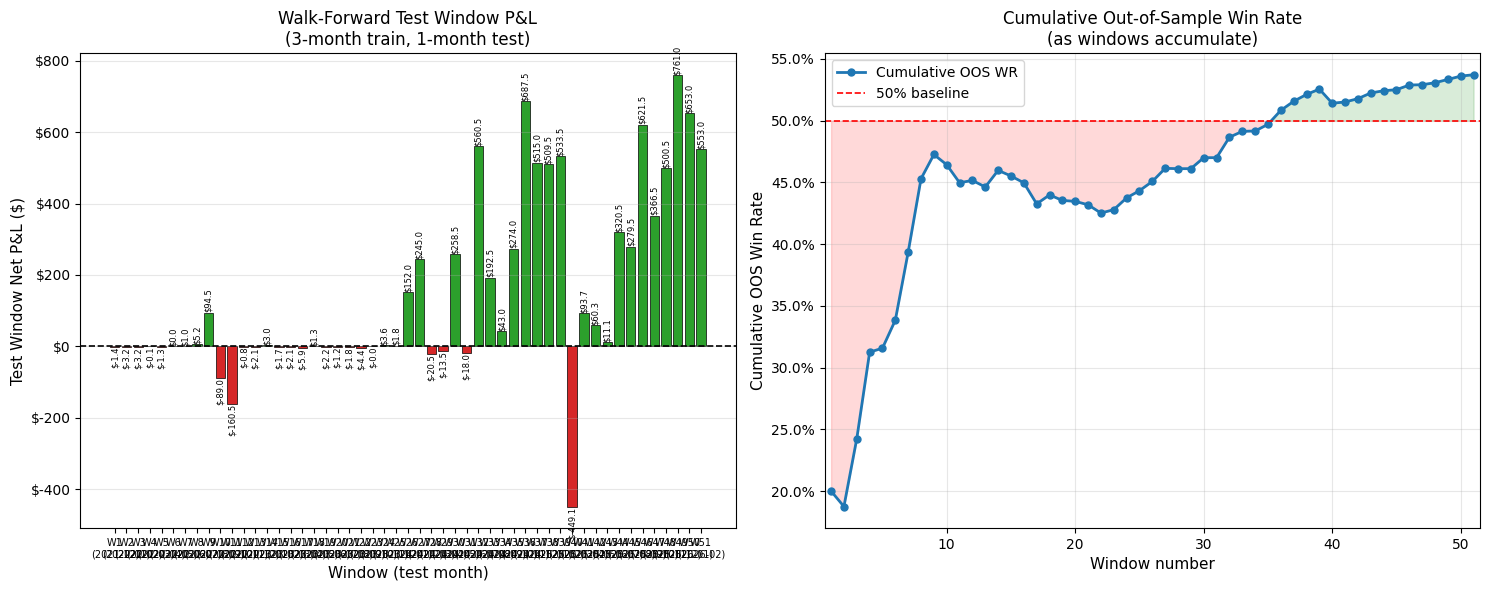

In [29]:
# Cell 16: Walk-Forward Optimization
#
# Rolls a 3-month train / 1-month test window across the full dataset (1-month step).
# For each window: derive Kelly from train → evaluate on held-out test month.
# Aggregates all out-of-sample (OOS) test windows to assess robustness vs. static split.

import io
import contextlib
from scipy import stats as scipy_stats

# ── Window generation ──────────────────────────────────────────────────────────
min_date = all_signals["created_time"].dt.normalize().min()
max_date = all_signals["created_time"].dt.normalize().max()

windows = []
train_start = min_date
while True:
    train_end  = train_start + pd.DateOffset(months=3)
    test_start = train_end
    test_end   = test_start + pd.DateOffset(months=1)
    if test_end > max_date + pd.Timedelta(days=1):
        break
    windows.append((train_start, train_end, test_start, test_end))
    train_start += pd.DateOffset(months=1)

print(f"Generated {len(windows)} walk-forward windows  "
      f"(3-month train, 1-month test, 1-month step).")
print(f"Full date range: {min_date.date()} – {max_date.date()}\n")

# ── Walk-forward loop ──────────────────────────────────────────────────────────
wf_records = []

for i, (tr_s, tr_e, te_s, te_e) in enumerate(windows):
    print(f"Running window {i+1}/{len(windows)}...", end="\r")

    # Slice train / test
    tr_mask = (all_signals["created_time"] >= tr_s) & (all_signals["created_time"] < tr_e)
    te_mask = (all_signals["created_time"] >= te_s) & (all_signals["created_time"] < te_e)
    w_train = all_signals[tr_mask].copy().reset_index(drop=True)
    w_test  = all_signals[te_mask].copy().reset_index(drop=True)

    train_n = len(w_train)
    test_n_raw = len(w_test)

    # Skip windows with insufficient data
    if train_n < 10 or test_n_raw < 5:
        continue

    # ── Train backtest (suppress output) ──────────────────────────────────────
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        w_train_results = run_backtest(
            signals          = w_train,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = TRAIN_CONTRACTS,
            kelly_fraction   = None,
            kelly_win_rate   = None,
            kelly_b          = None,
            slippage         = SLIPPAGE_CENTS,
            period_label     = f"WF-TRAIN {i+1}",
        )

    # ── Derive Kelly from train ────────────────────────────────────────────────
    w_train_exec = w_train_results[w_train_results["executed"] == True]
    w_wins   = w_train_exec[w_train_exec["no_won"] == True]["net_pnl"]
    w_losses = w_train_exec[w_train_exec["no_won"] == False]["net_pnl"]

    w_train_win_rate = w_train_exec["no_won"].mean() if len(w_train_exec) > 0 else 0.0
    w_avg_win  = w_wins.mean()             if len(w_wins)   > 0 else 0.0
    w_avg_loss = abs(w_losses.mean())      if len(w_losses) > 0 else 1e-9
    w_kelly_b  = w_avg_win / w_avg_loss

    w_kelly_f = KELLY_FRACTION * (w_train_win_rate * w_kelly_b - (1 - w_train_win_rate)) / w_kelly_b
    kelly_positive = w_kelly_f > 0

    # If Kelly is non-positive: test period uses MIN_CONTRACTS (floor in run_backtest)
    # We achieve this by passing kelly_f=0, which the sizing logic clips to MIN_CONTRACTS.
    effective_kelly_f    = max(0.0, w_kelly_f)
    effective_win_rate   = w_train_win_rate
    effective_kelly_b    = w_kelly_b

    # ── Test backtest (suppress output) ───────────────────────────────────────
    buf2 = io.StringIO()
    with contextlib.redirect_stdout(buf2):
        w_test_results = run_backtest(
            signals          = w_test,
            starting_balance = STARTING_BALANCE,
            fixed_contracts  = None if kelly_positive else MIN_CONTRACTS,
            kelly_fraction   = KELLY_FRACTION if kelly_positive else None,
            kelly_win_rate   = effective_win_rate if kelly_positive else None,
            kelly_b          = effective_kelly_b  if kelly_positive else None,
            slippage         = SLIPPAGE_CENTS,
            period_label     = f"WF-TEST {i+1}",
        )

    # ── Collect per-window stats ───────────────────────────────────────────────
    w_test_exec = w_test_results[w_test_results["executed"] == True]
    test_n_exec = len(w_test_exec)

    if test_n_exec > 0:
        test_net_pnl  = w_test_exec["net_pnl"].sum()
        test_win_rate = w_test_exec["no_won"].mean()
    else:
        test_net_pnl  = 0.0
        test_win_rate = float("nan")

    train_win_rate_val = w_train_win_rate
    test_roc_pct       = test_net_pnl / STARTING_BALANCE * 100

    wf_records.append({
        "window_id":       i + 1,
        "train_start":     str(tr_s.date()),
        "train_end":       str(tr_e.date()),
        "test_start":      str(te_s.date()),
        "test_end":        str(te_e.date()),
        "train_n":         train_n,
        "test_n":          test_n_exec,
        "train_win_rate":  train_win_rate_val,
        "test_win_rate":   test_win_rate,
        "test_net_pnl":    test_net_pnl,
        "test_roc_pct":    test_roc_pct,
        "kelly_f":         w_kelly_f,
        "kelly_positive":  kelly_positive,
    })

print(f"Done. {len(wf_records)} windows completed (of {len(windows)} generated).")

# ── Build results DataFrame ────────────────────────────────────────────────────
wf_df = pd.DataFrame(wf_records)

# ── Per-window table ───────────────────────────────────────────────────────────
print("\n" + "=" * 105)
print(f"{'Win':>4}  {'Train Period':>23}  {'Test Period':>23}  "
      f"{'Tr WR':>6}  {'Te WR':>6}  {'Te n':>5}  {'Test P&L':>10}  {'ROC%':>7}  {'K+':>3}")
print("=" * 105)
for _, r in wf_df.iterrows():
    tr_wr  = f"{r['train_win_rate']:.3f}" if not pd.isna(r["train_win_rate"]) else "  N/A"
    te_wr  = f"{r['test_win_rate']:.3f}"  if not pd.isna(r["test_win_rate"])  else "  N/A"
    k_flag = "Y" if r["kelly_positive"] else "N"
    print(f"{int(r['window_id']):>4}  "
          f"{r['train_start']} – {r['train_end']}  "
          f"{r['test_start']} – {r['test_end']}  "
          f"{tr_wr:>6}  {te_wr:>6}  "
          f"{int(r['test_n']):>5}  "
          f"${r['test_net_pnl']:>9.2f}  "
          f"{r['test_roc_pct']:>6.2f}%  "
          f"{k_flag:>3}")
print("=" * 105)

# ── Summary block ─────────────────────────────────────────────────────────────
total_windows        = len(wf_df)
kelly_pos_windows    = int(wf_df["kelly_positive"].sum())
profitable_windows   = int((wf_df["test_net_pnl"] > 0).sum())
overall_oos_pnl      = wf_df["test_net_pnl"].sum()
median_pnl           = wf_df["test_net_pnl"].median()
std_pnl              = wf_df["test_net_pnl"].std()

# Aggregate OOS win rate (pool all executed test trades)
total_oos_trades = int(wf_df["test_n"].sum())
# Reconstruct total wins: test_win_rate * test_n per window (round to nearest int)
total_oos_wins = int(round(
    (wf_df["test_win_rate"].fillna(0) * wf_df["test_n"]).sum()
))
overall_oos_wr = total_oos_wins / total_oos_trades if total_oos_trades > 0 else float("nan")

best_idx  = wf_df["test_net_pnl"].idxmax()
worst_idx = wf_df["test_net_pnl"].idxmin()
best_row  = wf_df.loc[best_idx]
worst_row = wf_df.loc[worst_idx]

print(f"\nWALK-FORWARD SUMMARY")
print(f"====================")
print(f"Total windows run         : {total_windows}")
print(f"Windows with Kelly > 0    : {kelly_pos_windows} ({kelly_pos_windows/total_windows*100:.0f}%)")
print(f"Profitable test windows   : {profitable_windows} ({profitable_windows/total_windows*100:.0f}%)")
print(f"Overall OOS win rate      : {overall_oos_wr:.4f}  (aggregate across all test windows combined)")
print(f"Overall OOS net P&L       : ${overall_oos_pnl:.2f} (sum of all test window P&L)")
print(f"Median test window P&L    : ${median_pnl:.2f}")
print(f"Std dev test window P&L   : ${std_pnl:.2f}")
_best_wr_str  = "N/A" if pd.isna(best_row["test_win_rate"])  else f"{best_row['test_win_rate']:.3f}"
_worst_wr_str = "N/A" if pd.isna(worst_row["test_win_rate"]) else f"{worst_row['test_win_rate']:.3f}"
print(f"Best window               : Window {int(best_row['window_id'])} "
      f"({best_row['test_start']} – {best_row['test_end']}, "
      f"P&L ${best_row['test_net_pnl']:.2f}, WR {_best_wr_str})")
print(f"Worst window              : Window {int(worst_row['window_id'])} "
      f"({worst_row['test_start']} – {worst_row['test_end']}, "
      f"P&L ${worst_row['test_net_pnl']:.2f}, WR {_worst_wr_str})")

# ── Binomial test on combined OOS win rate ─────────────────────────────────────
if total_oos_trades > 0:
    binom_result = scipy_stats.binomtest(
        total_oos_wins, total_oos_trades, p=0.5, alternative="greater"
    )
    print(f"\nCombined OOS binomial p-value: {binom_result.pvalue:.6f}")
    print(f"Combined OOS win rate        : {overall_oos_wr:.4f}  "
          f"({total_oos_wins} wins / {total_oos_trades} trades)")
    sig = "SIGNIFICANT (p < 0.05)" if binom_result.pvalue < 0.05 else "not significant at 0.05"
    print(f"Interpretation               : {sig}")

# ── Visualization ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# -- Panel 1: Bar chart of per-window test P&L ---------------------------------
bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in wf_df["test_net_pnl"]]
x_labels = [
    f"W{int(r['window_id'])}\n({r['test_start'][:7]})"
    for _, r in wf_df.iterrows()
]
bars = ax1.bar(range(len(wf_df)), wf_df["test_net_pnl"], color=bar_colors, edgecolor="black", linewidth=0.5)
ax1.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax1.set_xticks(range(len(wf_df)))
ax1.set_xticklabels(x_labels, fontsize=7)
ax1.set_xlabel("Window (test month)", fontsize=11)
ax1.set_ylabel("Test Window Net P&L ($)", fontsize=11)
ax1.set_title("Walk-Forward Test Window P&L\n(3-month train, 1-month test)", fontsize=12)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter("$%.0f"))
ax1.grid(axis="y", alpha=0.3)

# Annotate each bar with its value
for j, (bar, val) in enumerate(zip(bars, wf_df["test_net_pnl"])):
    va = "bottom" if val >= 0 else "top"
    offset = 0.5 if val >= 0 else -0.5
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + offset,
        f"${val:.1f}",
        ha="center", va=va, fontsize=6, rotation=90
    )

# -- Panel 2: Rolling cumulative OOS win rate ----------------------------------
cum_wins   = []
cum_trades = []
running_wins   = 0
running_trades = 0
for _, r in wf_df.iterrows():
    w = round(r["test_win_rate"] * r["test_n"]) if not pd.isna(r["test_win_rate"]) else 0
    running_wins   += w
    running_trades += r["test_n"]
    cum_wr = running_wins / running_trades if running_trades > 0 else float("nan")
    cum_wins.append(running_wins)
    cum_trades.append(running_trades)

cum_wr_series = [
    (w / t if t > 0 else float("nan"))
    for w, t in zip(cum_wins, cum_trades)
]

ax2.plot(
    range(1, len(wf_df) + 1),
    cum_wr_series,
    marker="o", markersize=5, linewidth=2, color="#1f77b4", label="Cumulative OOS WR"
)
ax2.axhline(0.50, color="red", linewidth=1.2, linestyle="--", label="50% baseline")
ax2.set_xlabel("Window number", fontsize=11)
ax2.set_ylabel("Cumulative OOS Win Rate", fontsize=11)
ax2.set_title("Cumulative Out-of-Sample Win Rate\n(as windows accumulate)", fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
ax2.legend(fontsize=10)
ax2.set_xlim(0.5, len(wf_df) + 0.5)
ax2.grid(alpha=0.3)

# Shade above/below 50%
ax2.fill_between(
    range(1, len(wf_df) + 1),
    cum_wr_series,
    0.50,
    where=[v >= 0.50 if not pd.isna(v) else False for v in cum_wr_series],
    alpha=0.15, color="green", interpolate=True
)
ax2.fill_between(
    range(1, len(wf_df) + 1),
    cum_wr_series,
    0.50,
    where=[v < 0.50 if not pd.isna(v) else False for v in cum_wr_series],
    alpha=0.15, color="red", interpolate=True
)

plt.tight_layout()
plt.show()


  ENTRY PRICE SUMMARY STATISTICS â€” TEST PERIOD

YES price at signal time:
count    1781.000000
mean        0.575188
std         0.029811
min         0.550000
25%         0.550000
50%         0.560000
75%         0.590000
max         0.650000

NO price paid (= actual_entry_no with slippage):
count    1781.000000
mean        0.464812
std         0.029811
min         0.390000
25%         0.450000
50%         0.480000
75%         0.490000
max         0.490000

  Mean NO price   : 0.4648
  Median NO price : 0.4800
  Std NO price    : 0.0298
  Min NO price    : 0.3900
  Max NO price    : 0.4900

  YES price sub-band distribution:
    [0.55, 0.58): 1117  (62.7%)
    [0.58, 0.61):  354  (19.9%)
    [0.61, 0.63):  111  (6.2%)
    [0.63, 0.65]:  199  (11.2%)

  Average entry NO price by city:
    MIA   : 0.4697
    LAX   : 0.4680
    DEN   : 0.4622
    NY    : 0.4587


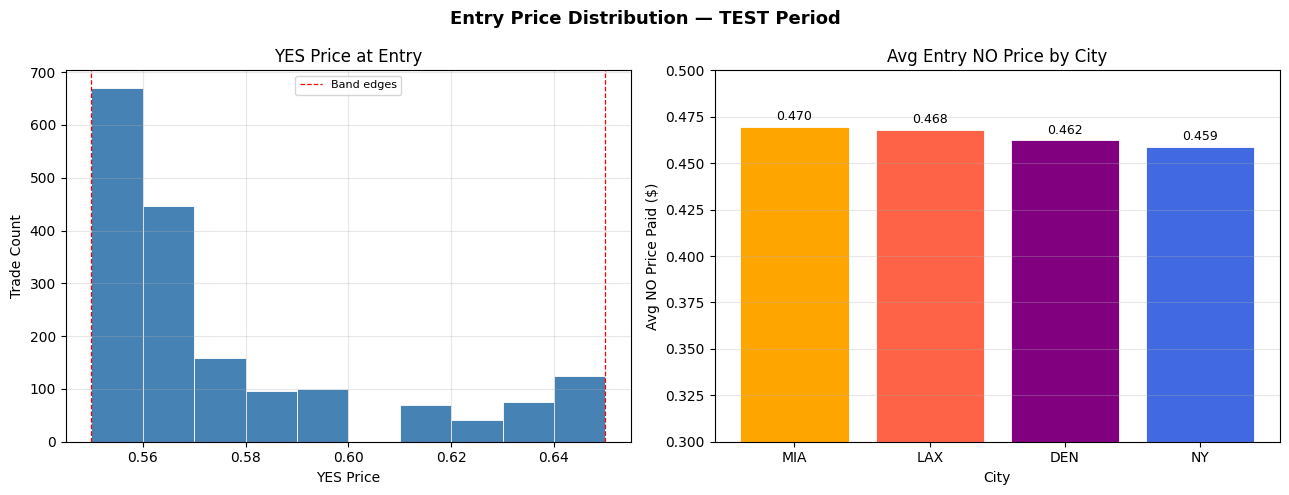

In [30]:
# Cell: Entry Price Summary Statistics
#
# Distribution analysis of YES prices at signal time and the corresponding NO prices paid.

import matplotlib.pyplot as plt
import numpy as np

_ep_df = test_results[test_results["executed"] == True].copy()
_ep_df["no_price_paid"] = _ep_df["actual_entry_no"]

# ── Describe stats ────────────────────────────────────────────────────────────
print("=" * 60)
print("  ENTRY PRICE SUMMARY STATISTICS — TEST PERIOD")
print("=" * 60)
print()
print("YES price at signal time:")
print(_ep_df["yes_price"].describe().to_string())
print()
print("NO price paid (= actual_entry_no with slippage):")
print(_ep_df["no_price_paid"].describe().to_string())
print()

# ── Mean / median / std / min / max of entry NO price ────────────────────────
_no = _ep_df["no_price_paid"]
print(f"  Mean NO price   : {_no.mean():.4f}")
print(f"  Median NO price : {_no.median():.4f}")
print(f"  Std NO price    : {_no.std():.4f}")
print(f"  Min NO price    : {_no.min():.4f}")
print(f"  Max NO price    : {_no.max():.4f}")
print()

# ── Sub-band breakdown of YES price ──────────────────────────────────────────
_yes     = _ep_df["yes_price"]
_n_total = len(_yes)
_bands = [
    ("[0.55, 0.58)", 0.55, 0.58),
    ("[0.58, 0.61)", 0.58, 0.61),
    ("[0.61, 0.63)", 0.61, 0.63),
    ("[0.63, 0.65]", 0.63, 0.651),
]
print("  YES price sub-band distribution:")
for _label, _lo, _hi in _bands:
    _count = int(((_yes >= _lo) & (_yes < _hi)).sum())
    _pct   = _count / _n_total * 100 if _n_total > 0 else 0.0
    print(f"    {_label}: {_count:>4}  ({_pct:.1f}%)")
print()

# ── Average entry NO price by city ───────────────────────────────────────────
_no_by_city = (
    _ep_df.groupby("city")["no_price_paid"]
    .mean()
    .sort_values(ascending=False)
)
print("  Average entry NO price by city:")
for _city, _avg in _no_by_city.items():
    print(f"    {_city:<6}: {_avg:.4f}")
print("=" * 60)

# ── Plots ─────────────────────────────────────────────────────────────────────
_fig, _axes = plt.subplots(1, 2, figsize=(13, 5))
_fig.suptitle("Entry Price Distribution — TEST Period", fontsize=13, fontweight="bold")

# Histogram of YES prices at entry
_ax0 = _axes[0]
_ax0.hist(
    _ep_df["yes_price"].dropna(),
    bins=10,
    range=(0.55, 0.65),
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
)
_ax0.set_title("YES Price at Entry")
_ax0.set_xlabel("YES Price")
_ax0.set_ylabel("Trade Count")
_ax0.axvline(0.55, color="red", linestyle="--", linewidth=0.9, label="Band edges")
_ax0.axvline(0.65, color="red", linestyle="--", linewidth=0.9)
_ax0.legend(fontsize=8)
_ax0.grid(True, alpha=0.3)

# Bar chart: average entry NO price by city
_ax1 = _axes[1]
_cities_sorted = _no_by_city.index.tolist()
_avgs_sorted   = _no_by_city.values.tolist()
_city_colors   = {"LAX": "tomato", "NY": "royalblue", "CHI": "green", "MIA": "orange", "DEN": "purple"}
_bar_colors    = [_city_colors.get(c, "gray") for c in _cities_sorted]
_ax1.bar(_cities_sorted, _avgs_sorted, color=_bar_colors, edgecolor="white", linewidth=0.6)
_ax1.set_title("Avg Entry NO Price by City")
_ax1.set_xlabel("City")
_ax1.set_ylabel("Avg NO Price Paid ($)")
_ax1.set_ylim(0.30, 0.50)
for _i, (_c, _v) in enumerate(zip(_cities_sorted, _avgs_sorted)):
    _ax1.text(_i, _v + 0.002, f"{_v:.3f}", ha="center", va="bottom", fontsize=9)
_ax1.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## Strategy 2: Falling Into Range NO

**Strategy**: Buy NO contracts when YES price falls *into* the 55–65¢ range from above.

**Entry condition**: YES price was previously above 0.65, then drops into [0.55, 0.65].  
No taker-side filter, no slope check — price direction only.

**Exit**: Hold to settlement (same as Strategy 1).

**Train period**: 2023–2024 (fixed 10 contracts)  
**Test period**: 2025–2026 (half-Kelly sizing locked from train)

In [64]:
# Strategy 2: Falling Into Range NO — Signal Generation + Train/Test Split
#
# Entry: YES price drops INTO [YES_LOW, YES_HIGH] from above YES_HIGH.
# One entry per ticker (first qualifying trade), pre-noon local-time filter applied.

from zoneinfo import ZoneInfo as _S2_ZI


def build_fall_signal_df() -> pd.DataFrame:
    """Return signals where YES price falls into [YES_LOW, YES_HIGH] from above YES_HIGH."""
    signal_rows = []

    for city, prefix in CITIES.items():
        trades  = trades_dfs[city].copy()
        markets = markets_dfs[city][['ticker', 'settlement_value', 'yes_won', 'close_time']].copy()
        local_tz = _S2_ZI(CITY_TIMEZONES[city])

        city_signals = []

        for ticker, grp in trades.groupby('ticker'):
            grp = grp.sort_values('created_time').reset_index(drop=True)
            had_prior_high = False
            signal_taken   = False

            for _, row in grp.iterrows():
                if signal_taken:
                    break
                yes_p = row['yes_price_dollars']

                if yes_p > YES_HIGH:
                    had_prior_high = True
                    continue

                if had_prior_high and YES_LOW <= yes_p <= YES_HIGH:
                    city_signals.append(row)
                    signal_taken = True

        if not city_signals:
            print(f"{city}: no falling-into-range signals")
            continue

        signals = pd.DataFrame(city_signals).reset_index(drop=True)

        # ── Pre-noon local-time filter ───────────────────────────────────────────
        signals['local_hour'] = signals['created_time'].dt.tz_convert(local_tz).dt.hour
        before_filter = len(signals)
        signals = signals[signals['local_hour'] < 12].copy()
        after_filter  = len(signals)
        print(f"  {city}: {before_filter - after_filter} signals dropped (post-noon), {after_filter} remain")
        signals = signals.drop(columns=['local_hour'])

        if signals.empty:
            print(f"{city}: no signals remain after pre-noon filter")
            continue

        # ── Merge settlement data ──────────────────────────────────────────────────
        merged = signals.merge(markets, on='ticker', how='left')
        merged = merged.dropna(subset=['settlement_value'])
        if merged.empty:
            print(f"{city}: signals found but no settlement data after merge")
            continue

        merged['no_won'] = ~merged['yes_won']
        merged['city']   = city
        signal_rows.append(merged)
        print(f"{city}: {len(merged):4d} falling-into-range signals after all filters")

    if not signal_rows:
        raise ValueError("No falling-into-range signals found.")

    df = pd.concat(signal_rows, ignore_index=True)
    df = df.sort_values('created_time').reset_index(drop=True)
    return df


s2_all_signals = build_fall_signal_df()

# ── Train / Test split ────────────────────────────────────────────────────────────────────────
s2_train_signals = s2_all_signals[
    (s2_all_signals['created_time'] >= TRAIN_START) &
    (s2_all_signals['created_time'] <  TRAIN_CUTOFF)
].copy().reset_index(drop=True)

s2_test_signals = s2_all_signals[
    s2_all_signals['created_time'] >= TRAIN_CUTOFF
].copy().reset_index(drop=True)

print(f"\nTotal signals  : {len(s2_all_signals)}")
print(f"Train signals  : {len(s2_train_signals)}  "
      f"({s2_train_signals['created_time'].min().date()} – {s2_train_signals['created_time'].max().date()})")
print(f"Test signals   : {len(s2_test_signals)}  "
      f"({s2_test_signals['created_time'].min().date()} – {s2_test_signals['created_time'].max().date()})")


  LAX: 270 signals dropped (post-noon), 430 remain
LAX:  430 falling-into-range signals after all filters
  NY: 959 signals dropped (post-noon), 629 remain
NY:  629 falling-into-range signals after all filters
  MIA: 542 signals dropped (post-noon), 442 remain
MIA:  442 falling-into-range signals after all filters
  DEN: 542 signals dropped (post-noon), 180 remain
DEN:  180 falling-into-range signals after all filters

Total signals  : 1681
Train signals  : 342  (2023-01-02 – 2024-12-31)
Test signals   : 1195  (2025-01-02 – 2026-03-13)


In [65]:
# Strategy 2: Falling Into Range NO — Train Backtest

s2_train_results = run_backtest(
    signals          = s2_train_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = TRAIN_CONTRACTS,
    kelly_fraction   = None,
    kelly_win_rate   = None,
    kelly_b          = None,
    slippage         = SLIPPAGE_CENTS,
    period_label     = "S2 TRAIN (2023–2024)",
)

# ── Derive Kelly parameters from train results ───────────────────────────────────
s2_train_exec = s2_train_results[s2_train_results['executed'] == True]
s2_wins       = s2_train_exec[s2_train_exec['no_won'] == True]['net_pnl']
s2_losses     = s2_train_exec[s2_train_exec['no_won'] == False]['net_pnl']

s2_train_win_rate = s2_train_exec['no_won'].mean() if len(s2_train_exec) > 0 else 0.0
s2_avg_win        = s2_wins.mean()              if len(s2_wins)   > 0 else 0.0
s2_avg_loss       = abs(s2_losses.mean())       if len(s2_losses) > 0 else 1e-9
s2_kelly_b        = s2_avg_win / s2_avg_loss

print(f"\nKelly parameters derived from S2 TRAIN period:")
print(f"  Win rate   : {s2_train_win_rate:.4f}")
print(f"  Avg win    : ${s2_avg_win:.4f}")
print(f"  Avg loss   : ${s2_avg_loss:.4f}")
print(f"  b ratio    : {s2_kelly_b:.4f}")
s2_raw_kelly = KELLY_FRACTION * (s2_train_win_rate * s2_kelly_b - (1 - s2_train_win_rate)) / s2_kelly_b
print(f"  Half-Kelly f*: {s2_raw_kelly:.4f} (fraction of bankroll per trade)")



S2 TRAIN (2023–2024): 342/342 trades executed
  No ruin. Final balance: $702.20

Kelly parameters derived from S2 TRAIN period:
  Win rate   : 0.5029
  Avg win    : $5.5506
  Avg loss   : $4.4265
  b ratio    : 1.2540
  Half-Kelly f*: 0.0533 (fraction of bankroll per trade)


In [66]:
# Strategy 2: Falling Into Range NO — Train Risk Metrics

s2_train_metrics = compute_risk_metrics(s2_train_results, STARTING_BALANCE, "S2 TRAIN (2023–2024)")


  S2 TRAIN (2023–2024) — RESULTS
  Total input trades   : 342
  Executed trades      : 342
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Skipped (funds)      : 0
  Win rate             : 50.29%
  Gross P&L            : $270.60
  Total fees           : $68.40
  Net P&L              : $202.20
  Avg edge / trade     : $0.5912
  Return on Capital    : 40.44%  (on $500 starting)
  Profit Factor        : 1.269
  Max Drawdown ($)     : $-106.10
  Max Drawdown (%)     : -19.40%
  Sharpe Ratio (ann.)  : 2.385
  Longest losing streak: 10
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee net_pnl avg_edge
 DEN      13    38.5%    $-3.20     $2.60  $-5.80 $-0.4462
 MIA     137    50.4%   $110.00    $27.40  $82.60  $0.6029
  NY     192    51.0%   $163.80    $38.40 $125.40  $0.6531



In [67]:
# Strategy 2: Falling Into Range NO — Test Backtest (Kelly sizing locked from train)

s2_raw_kelly_f = KELLY_FRACTION * (s2_train_win_rate * s2_kelly_b - (1 - s2_train_win_rate)) / s2_kelly_b
if s2_raw_kelly_f <= 0:
    print("WARNING: S2 Kelly fraction <= 0 — proceeding with MIN_CONTRACTS floor.")

s2_test_results = run_backtest(
    signals          = s2_test_signals,
    starting_balance = STARTING_BALANCE,
    fixed_contracts  = None,
    kelly_fraction   = KELLY_FRACTION,
    kelly_win_rate   = s2_train_win_rate,
    kelly_b          = s2_kelly_b,
    slippage         = SLIPPAGE_CENTS,
    period_label     = "S2 TEST (2025–2026)",
)



S2 TEST (2025–2026): 1195/1195 trades executed
  No ruin. Final balance: $6.80


In [68]:
# Strategy 2: Falling Into Range NO — Test Risk Metrics

s2_test_metrics = compute_risk_metrics(s2_test_results, STARTING_BALANCE, "S2 TEST (2025–2026)")


  S2 TEST (2025–2026) — RESULTS
  Total input trades   : 1195
  Executed trades      : 1195
  Skipped (slippage)   : 0
  Skipped (ruin)       : 0
  Skipped (funds)      : 0
  Win rate             : 42.18%
  Gross P&L            : $114.30
  Total fees           : $607.50
  Net P&L              : $-493.20
  Avg edge / trade     : $-0.4127
  Return on Capital    : -98.64%  (on $500 starting)
  Profit Factor        : 0.936
  Max Drawdown ($)     : $-874.17
  Max Drawdown (%)     : -99.53%
  Sharpe Ratio (ann.)  : -0.712
  Longest losing streak: 12
  Ruin occurred        : False

City-level breakdown:
city  trades win_rate gross_pnl total_fee  net_pnl avg_edge
 DEN     167    40.7%   $-51.09    $88.80 $-139.89 $-0.8377
 LAX     430    41.4%  $-100.82   $211.12 $-311.94 $-0.7254
 MIA     305    42.3%    $64.37   $162.16  $-97.79 $-0.3206
  NY     293    44.0%   $201.84   $145.42   $56.42  $0.1926



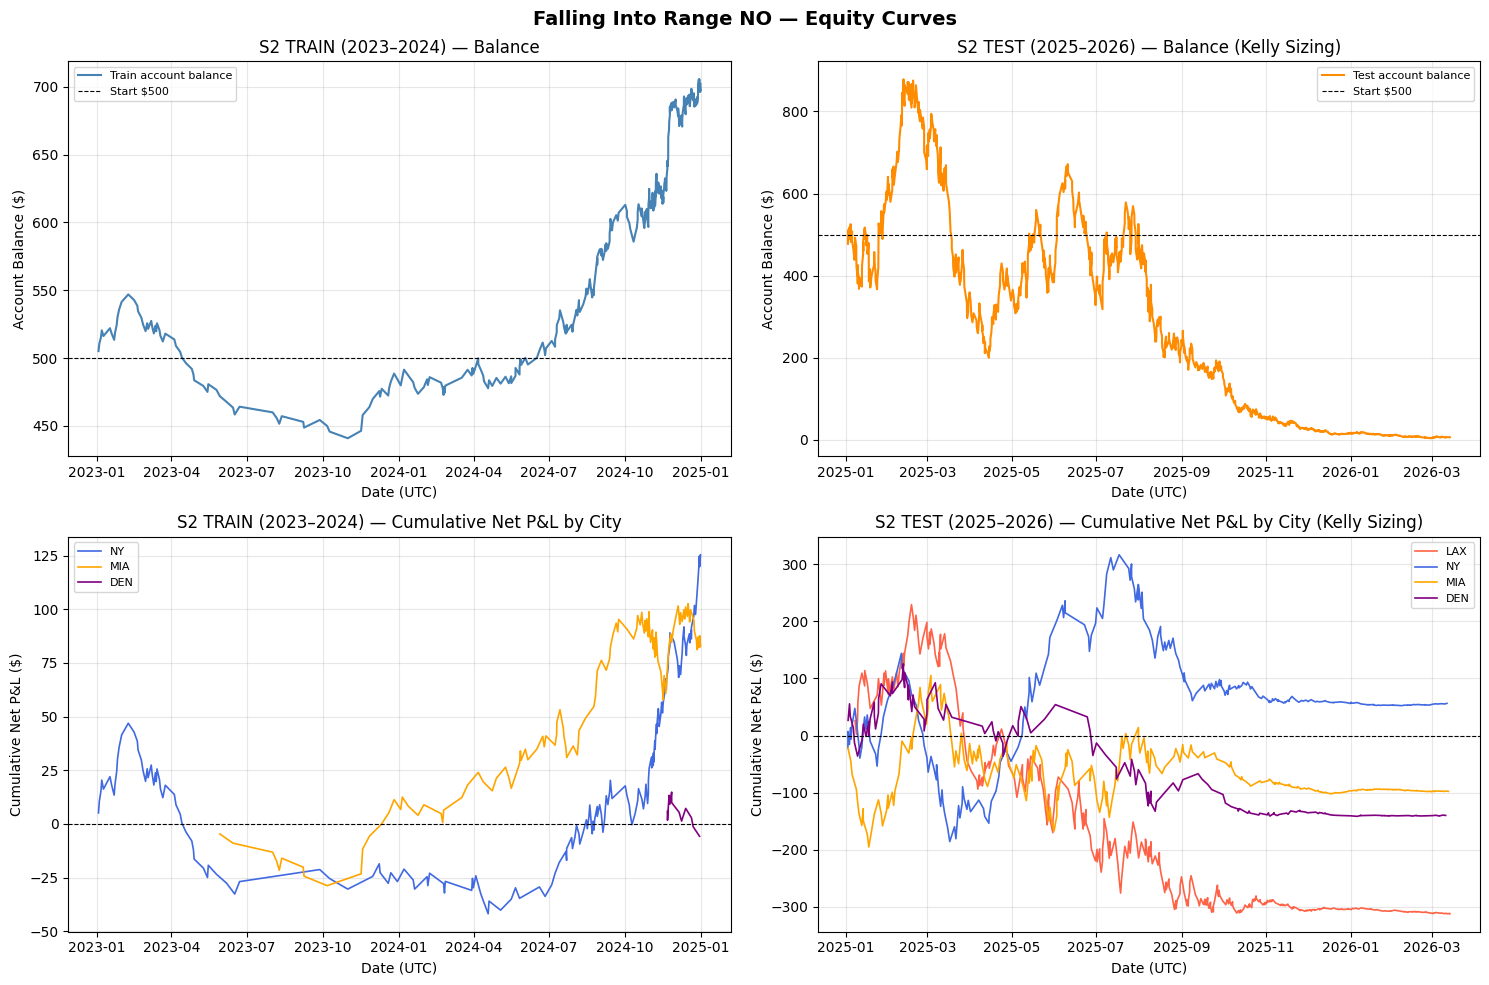

In [69]:
# Strategy 2: Falling Into Range NO — Equity Curves

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Falling Into Range NO — Equity Curves", fontsize=14, fontweight="bold")

s2_city_colors = {"LAX": "tomato", "NY": "royalblue", "CHI": "green", "MIA": "orange", "DEN": "purple"}

# ── (0,0) Train balance ─────────────────────────────────────────────────────────────────
ax = axes[0, 0]
s2_tr_exec = s2_train_results[s2_train_results["executed"] == True]
if not s2_tr_exec.empty:
    ax.plot(s2_tr_exec["created_time"].values,
            (STARTING_BALANCE + s2_tr_exec["net_pnl"].cumsum()).values,
            color="steelblue", linewidth=1.5, label="Train account balance")
ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--",
           label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("S2 TRAIN (2023–2024) — Balance")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Account Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (0,1) Test balance ──────────────────────────────────────────────────────────────────
ax = axes[0, 1]
s2_te_exec = s2_test_results[s2_test_results["executed"] == True]
if not s2_te_exec.empty:
    ax.plot(s2_te_exec["created_time"].values,
            (STARTING_BALANCE + s2_te_exec["net_pnl"].cumsum()).values,
            color="darkorange", linewidth=1.5, label="Test account balance")
ax.axhline(STARTING_BALANCE, color="black", linewidth=0.8, linestyle="--",
           label=f"Start ${STARTING_BALANCE:.0f}")
ax.set_title("S2 TEST (2025–2026) — Balance (Kelly Sizing)")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Account Balance ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,0) Train P&L by city ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
for city in CITIES:
    cdf = s2_tr_exec[s2_tr_exec["city"] == city].sort_values("created_time")
    if cdf.empty:
        continue
    ax.plot(cdf["created_time"].values, cdf["net_pnl"].cumsum().values,
            label=city, color=s2_city_colors.get(city, "gray"), linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("S2 TRAIN (2023–2024) — Cumulative Net P&L by City")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── (1,1) Test P&L by city ────────────────────────────────────────────────────────────────
ax = axes[1, 1]
for city in CITIES:
    cdf = s2_te_exec[s2_te_exec["city"] == city].sort_values("created_time")
    if cdf.empty:
        continue
    ax.plot(cdf["created_time"].values, cdf["net_pnl"].cumsum().values,
            label=city, color=s2_city_colors.get(city, "gray"), linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("S2 TEST (2025–2026) — Cumulative Net P&L by City (Kelly Sizing)")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Cumulative Net P&L ($)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


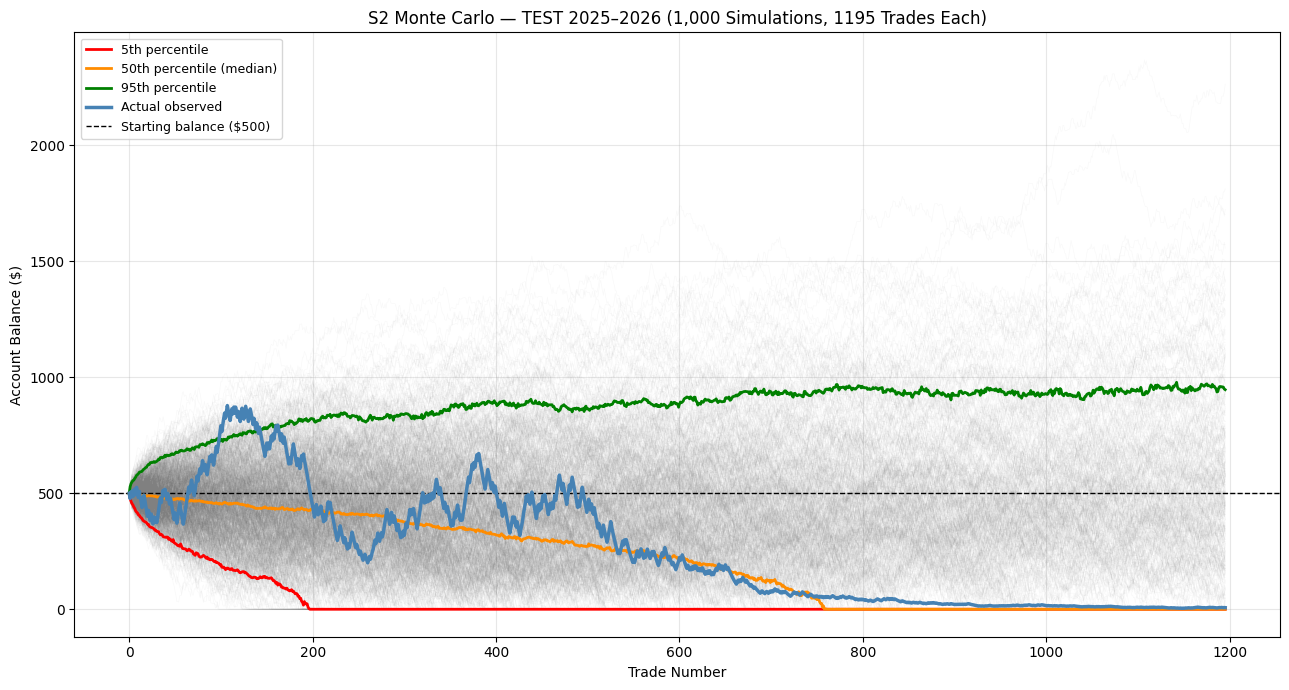

  S2 MONTE CARLO SUMMARY — TEST PERIOD (2025–2026)
  Simulations run       : 1,000
  Trades per simulation : 1195
  % simulations ruined  : 67.5%
  Median final balance  : $0.00
  5th pct final balance : $0.00
  95th pct final balance: $946.80


In [70]:
# Strategy 2: Falling Into Range NO — Monte Carlo Simulation (Test Period)

s2_N_SIMS = 1000
s2_rng    = np.random.default_rng(seed=42)

s2_test_exec_pnl = s2_test_results.loc[s2_test_results["executed"] == True, "net_pnl"].values
s2_n_test_trades = len(s2_test_exec_pnl)

if s2_n_test_trades == 0:
    print("No executed S2 test trades — skipping Monte Carlo.")
else:
    s2_actual_curve = np.concatenate([[STARTING_BALANCE],
                                       STARTING_BALANCE + np.cumsum(s2_test_exec_pnl)])
    s2_actual_curve = np.maximum(s2_actual_curve, 0.0)

    s2_sim_final  = np.empty(s2_N_SIMS)
    s2_sim_curves = np.empty((s2_N_SIMS, s2_n_test_trades + 1))

    for _s in range(s2_N_SIMS):
        _sampled  = s2_rng.choice(s2_test_exec_pnl, size=s2_n_test_trades, replace=True)
        _curve    = np.empty(s2_n_test_trades + 1)
        _curve[0] = STARTING_BALANCE
        _ruined   = False
        for _i, _pnl in enumerate(_sampled):
            if _ruined:
                _curve[_i + 1] = 0.0
            else:
                _new = _curve[_i] + _pnl
                if _new <= 0:
                    _new   = 0.0
                    _ruined = True
                _curve[_i + 1] = _new
        s2_sim_curves[_s] = _curve
        s2_sim_final[_s]  = _curve[-1]

    s2_p05 = np.percentile(s2_sim_curves, 5,  axis=0)
    s2_p50 = np.percentile(s2_sim_curves, 50, axis=0)
    s2_p95 = np.percentile(s2_sim_curves, 95, axis=0)

    x_ax = np.arange(s2_n_test_trades + 1)
    fig, ax = plt.subplots(figsize=(13, 7))
    for _s in range(s2_N_SIMS):
        ax.plot(x_ax, s2_sim_curves[_s], color="gray", alpha=0.05, linewidth=0.5)
    ax.plot(x_ax, s2_p05, color="red",        linewidth=2.0, label="5th percentile",           zorder=4)
    ax.plot(x_ax, s2_p50, color="darkorange",  linewidth=2.0, label="50th percentile (median)", zorder=4)
    ax.plot(x_ax, s2_p95, color="green",       linewidth=2.0, label="95th percentile",          zorder=4)
    ax.plot(x_ax, s2_actual_curve, color="steelblue", linewidth=2.5, label="Actual observed",   zorder=5)
    ax.axhline(STARTING_BALANCE, color="black", linewidth=1.0, linestyle="--",
               label=f"Starting balance (${STARTING_BALANCE:.0f})", zorder=3)
    ax.set_title(
        f"S2 Monte Carlo — TEST 2025–2026 ({s2_N_SIMS:,} Simulations, {s2_n_test_trades} Trades Each)",
        fontsize=12,
    )
    ax.set_xlabel("Trade Number")
    ax.set_ylabel("Account Balance ($)")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pct_ruined   = (s2_sim_final == 0.0).mean() * 100
    print("=" * 55)
    print("  S2 MONTE CARLO SUMMARY — TEST PERIOD (2025–2026)")
    print("=" * 55)
    print(f"  Simulations run       : {s2_N_SIMS:,}")
    print(f"  Trades per simulation : {s2_n_test_trades}")
    print(f"  % simulations ruined  : {pct_ruined:.1f}%")
    print(f"  Median final balance  : ${np.median(s2_sim_final):.2f}")
    print(f"  5th pct final balance : ${np.percentile(s2_sim_final, 5):.2f}")
    print(f"  95th pct final balance: ${np.percentile(s2_sim_final, 95):.2f}")
    print("=" * 55)


In [71]:
# Strategy 2: Falling Into Range NO — Statistical Significance Tests

run_significance_tests(s2_train_results, "S2 TRAIN (2023–2024)")
run_significance_tests(s2_test_results,  "S2 TEST (2025–2026)")


  STATISTICAL SIGNIFICANCE — S2 TRAIN (2023–2024)
  Trades: 342  |  Wins: 172  |  Losses: 170  |  Win Rate: 0.5029

  [1] BINOMIAL TEST  (H0: p=0.5, H1: p>0.5, one-sided)
      Observed win rate : 0.5029
      n_wins / n_trades  : 172 / 342
      p-value            : 0.478443
      Verdict            : NOT significant at alpha=0.05

  [2] ONE-SAMPLE T-TEST  (H0: mean_pnl=0, H1: mean_pnl>0, one-sided)
      Mean P&L / trade   : $0.5912
      t-statistic        : 2.1840
      p-value            : 0.014823
      95% CI lower bound : $0.1447  (upper: +inf)
      Verdict            : SIGNIFICANT at alpha=0.05

  [3] Z-TEST ON WIN RATE  (H0: p=0.5, H1: p>0.5, one-sided)
      Z-score            : 0.1081
      p-value            : 0.456939
      Verdict            : NOT significant at alpha=0.05

  [4] MINIMUM TRADES FOR 80% POWER (informational)
      Observed effect (p - 0.5): 0.0029
      Trades needed (80% power) : 180785
      Trades available          : 342
      Assessment             

S2 walk-forward: 52 windows (2021-08-13 – 2026-03-13)
  Walk-forward complete.         

S2 Walk-Forward Results:
 window train_start test_start   test_end  train_n  test_n train_wr test_wr kelly_f test_pnl
      1  2021-08-13 2021-11-13 2021-12-13       14       6    50.0%   16.7%  0.0568  $-87.00
      2  2021-09-13 2021-12-13 2022-01-13       18       5    44.4%   40.0%  0.0010   $-0.12
      3  2021-10-13 2022-01-13 2022-02-13       17       8    35.3%    0.0%  0.0000   $-3.47
      4  2021-11-13 2022-02-13 2022-03-13       19       6    15.8%   16.7%  0.0000   $-1.52
      5  2021-12-13 2022-03-13 2022-04-13       19       7    15.8%   57.1%  0.0000    $0.90
      7  2022-02-13 2022-05-13 2022-06-13       14       6    35.7%   33.3%  0.0000   $-0.65
      8  2022-03-13 2022-06-13 2022-07-13       14      11    42.9%   27.3%  0.0000   $-1.89
      9  2022-04-13 2022-07-13 2022-08-13       18      12    27.8%   58.3%  0.0000    $1.68
     10  2022-05-13 2022-08-13 2022-09-13       2

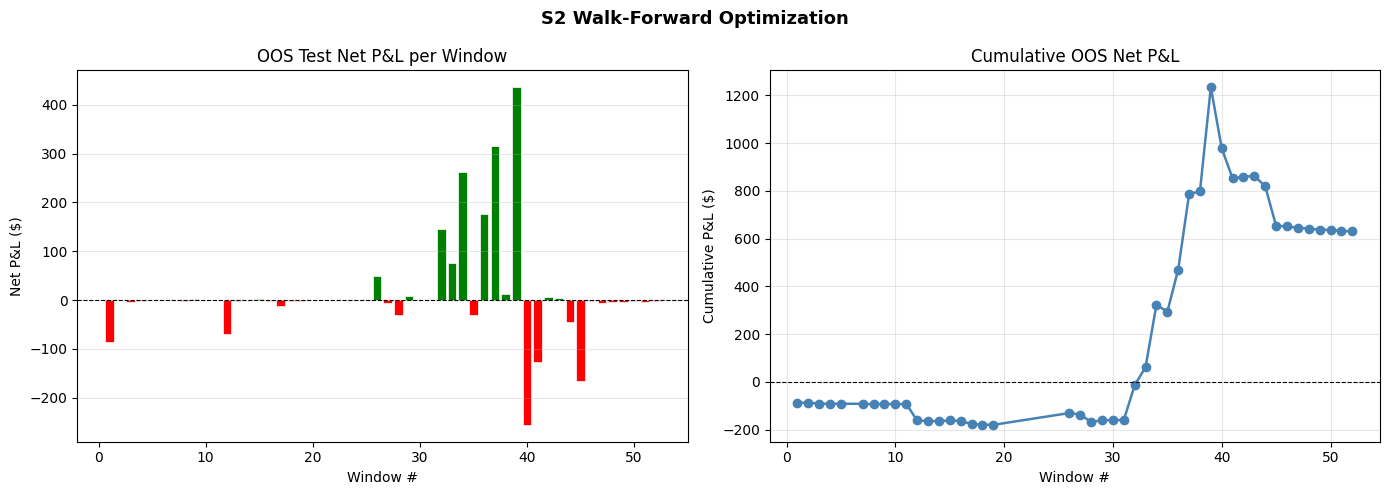


  OOS windows profitable : 16/45
  Mean OOS win rate       : 40.85%
  Total OOS P&L           : $630.12


In [72]:
# Strategy 2: Falling Into Range NO — Walk-Forward Optimization
#
# 3-month train / 1-month test rolling windows, 1-month step.

import io as _s2_io
import contextlib as _s2_ctx

s2_min_date = s2_all_signals["created_time"].dt.normalize().min()
s2_max_date = s2_all_signals["created_time"].dt.normalize().max()

s2_windows = []
_wf_start = s2_min_date
while True:
    _tr_end = _wf_start + pd.DateOffset(months=3)
    _te_end = _tr_end   + pd.DateOffset(months=1)
    if _te_end > s2_max_date + pd.Timedelta(days=1):
        break
    s2_windows.append((_wf_start, _tr_end, _tr_end, _te_end))
    _wf_start += pd.DateOffset(months=1)

print(f"S2 walk-forward: {len(s2_windows)} windows ({s2_min_date.date()} – {s2_max_date.date()})")

s2_wf_records = []

for _i, (_tr_s, _tr_e, _te_s, _te_e) in enumerate(s2_windows):
    print(f"  Window {_i+1}/{len(s2_windows)}...", end="\r")
    _w_tr = s2_all_signals[
        (s2_all_signals["created_time"] >= _tr_s) &
        (s2_all_signals["created_time"] <  _tr_e)
    ].copy().reset_index(drop=True)
    _w_te = s2_all_signals[
        (s2_all_signals["created_time"] >= _te_s) &
        (s2_all_signals["created_time"] <  _te_e)
    ].copy().reset_index(drop=True)
    if len(_w_tr) < 10 or len(_w_te) < 5:
        continue

    _buf = _s2_io.StringIO()
    with _s2_ctx.redirect_stdout(_buf):
        _tr_res = run_backtest(_w_tr, STARTING_BALANCE, TRAIN_CONTRACTS,
                               None, None, None, SLIPPAGE_CENTS, "")

    _tr_exec = _tr_res[_tr_res["executed"] == True]
    _tr_wr   = _tr_exec["no_won"].mean() if len(_tr_exec) > 0 else 0.0
    _w_wins  = _tr_exec[_tr_exec["no_won"] == True]["net_pnl"]
    _w_loss  = _tr_exec[_tr_exec["no_won"] == False]["net_pnl"]
    _wkb     = (_w_wins.mean() / abs(_w_loss.mean())
                if len(_w_wins) > 0 and len(_w_loss) > 0 else 1.0)
    _wkf     = max(0.0, KELLY_FRACTION * (_tr_wr * _wkb - (1 - _tr_wr)) / _wkb)

    _buf2 = _s2_io.StringIO()
    with _s2_ctx.redirect_stdout(_buf2):
        _te_res = run_backtest(_w_te, STARTING_BALANCE, None,
                               KELLY_FRACTION, _tr_wr, _wkb, SLIPPAGE_CENTS, "")

    _te_exec = _te_res[_te_res["executed"] == True]
    s2_wf_records.append({
        "window":      _i + 1,
        "train_start": _tr_s.date(),
        "test_start":  _te_s.date(),
        "test_end":    _te_e.date(),
        "train_n":     len(_tr_exec),
        "test_n":      len(_te_exec),
        "train_wr":    _tr_wr,
        "test_wr":     _te_exec["no_won"].mean() if len(_te_exec) > 0 else float("nan"),
        "kelly_f":     _wkf,
        "test_pnl":    _te_exec["net_pnl"].sum(),
    })

print("  Walk-forward complete.         ")

s2_wf_df = pd.DataFrame(s2_wf_records)
if not s2_wf_df.empty:
    _disp = s2_wf_df.copy()
    _disp["train_wr"] = _disp["train_wr"].map("{:.1%}".format)
    _disp["test_wr"]  = _disp["test_wr"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
    _disp["kelly_f"]  = _disp["kelly_f"].map("{:.4f}".format)
    _disp["test_pnl"] = _disp["test_pnl"].map("${:.2f}".format)
    print("\nS2 Walk-Forward Results:")
    print(_disp.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("S2 Walk-Forward Optimization", fontsize=13, fontweight="bold")

    ax = axes[0]
    _pnls = s2_wf_df["test_pnl"].values
    ax.bar(s2_wf_df["window"], _pnls,
           color=["green" if p >= 0 else "red" for p in _pnls],
           edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("OOS Test Net P&L per Window")
    ax.set_xlabel("Window #")
    ax.set_ylabel("Net P&L ($)")
    ax.grid(True, alpha=0.3, axis="y")

    ax = axes[1]
    ax.plot(s2_wf_df["window"], s2_wf_df["test_pnl"].cumsum().values,
            marker="o", color="steelblue", linewidth=1.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Cumulative OOS Net P&L")
    ax.set_xlabel("Window #")
    ax.set_ylabel("Cumulative P&L ($)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    _pos = (s2_wf_df["test_pnl"] > 0).sum()
    print(f"\n  OOS windows profitable : {_pos}/{len(s2_wf_df)}")
    print(f"  Mean OOS win rate       : {s2_wf_df['test_wr'].dropna().mean():.2%}")
    print(f"  Total OOS P&L           : ${s2_wf_df['test_pnl'].sum():.2f}")


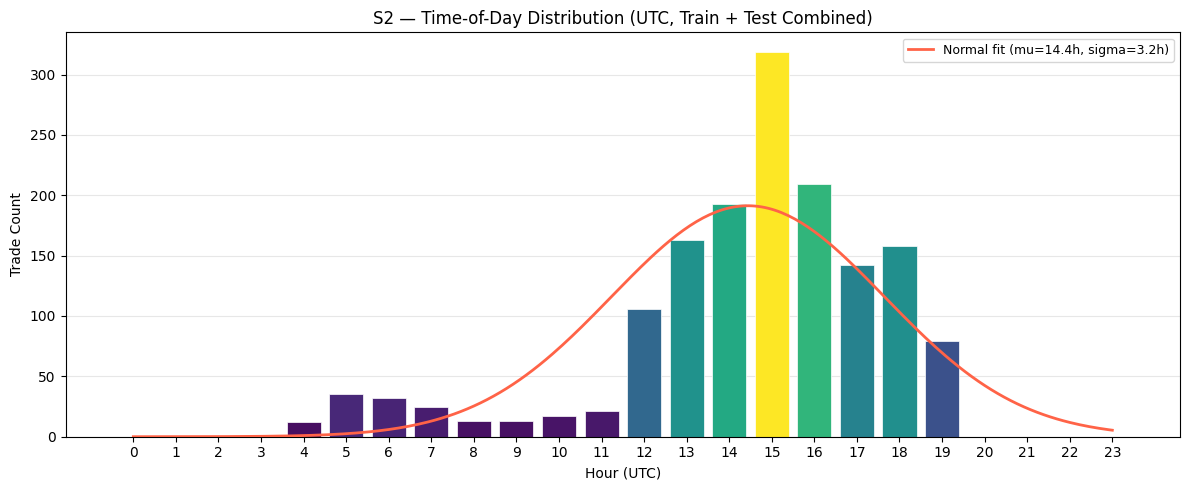

Peak trade hour (UTC): 15:00
Total executed trades: 1537


In [73]:
# Strategy 2: Falling Into Range NO — Time-of-Day Distribution

import scipy.stats as _s2_stats_tod

s2_all_tod = pd.concat([
    s2_train_results[s2_train_results["executed"] == True],
    s2_test_results[s2_test_results["executed"] == True],
], ignore_index=True)

if s2_all_tod.empty:
    print("No executed S2 trades — skipping time-of-day analysis.")
else:
    s2_all_tod["hour_utc"] = s2_all_tod["created_time"].dt.hour
    s2_hour_counts = s2_all_tod.groupby("hour_utc").size().reindex(range(24), fill_value=0)

    _raw_h   = s2_all_tod["hour_utc"].values
    _mu, _sg = _s2_stats_tod.norm.fit(_raw_h)
    _xs      = np.linspace(0, 23, 300)
    _pdf_sc  = _s2_stats_tod.norm.pdf(_xs, _mu, _sg) * len(_raw_h)

    _norm_c = s2_hour_counts.values / max(s2_hour_counts.values)
    _colors = [plt.cm.viridis(v) for v in _norm_c]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(s2_hour_counts.index, s2_hour_counts.values,
           color=_colors, edgecolor="white", linewidth=0.5, zorder=2)
    ax.plot(_xs, _pdf_sc, color="tomato", linewidth=2.0, zorder=3,
            label=f"Normal fit (mu={_mu:.1f}h, sigma={_sg:.1f}h)")
    ax.set_title("S2 — Time-of-Day Distribution (UTC, Train + Test Combined)")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Trade Count")
    ax.set_xticks(range(24))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    print(f"Peak trade hour (UTC): {s2_hour_counts.idxmax()}:00")
    print(f"Total executed trades: {len(s2_all_tod)}")


  S2 ENTRY PRICE SUMMARY STATISTICS — TEST PERIOD

YES price at signal time:
count    1195.000000
mean        0.616092
std         0.032617
min         0.550000
25%         0.590000
50%         0.630000
75%         0.650000
max         0.650000

NO price paid (actual_entry_no with slippage):
count    1195.000000
mean        0.423908
std         0.032617
min         0.390000
25%         0.390000
50%         0.410000
75%         0.450000
max         0.490000

  Mean NO price   : 0.4239
  Median NO price : 0.4100
  Std NO price    : 0.0326
  Min NO price    : 0.3900
  Max NO price    : 0.4900

  YES price sub-band distribution:
    [0.55, 0.58):  180  (15.1%)
    [0.58, 0.61):  230  (19.2%)
    [0.61, 0.63):  182  (15.2%)
    [0.63, 0.65]:  603  (50.5%)

  Average entry NO price by city:
    DEN   : 0.4251
    MIA   : 0.4251
    LAX   : 0.4238
    NY    : 0.4221


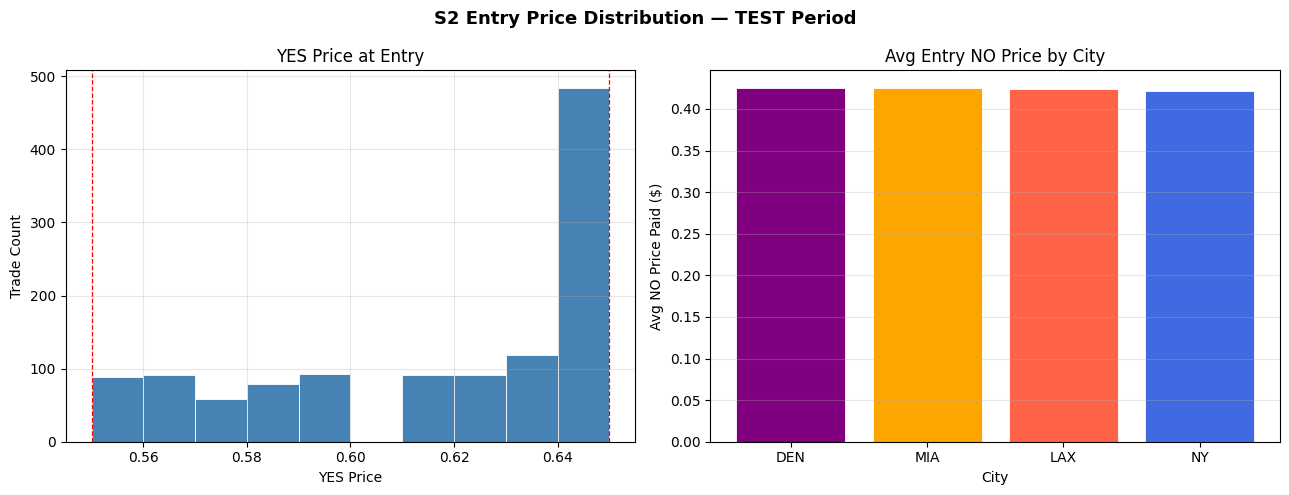

In [74]:
# Strategy 2: Falling Into Range NO — Entry Price Summary Statistics

_s2_ep = s2_test_results[s2_test_results["executed"] == True].copy()
_s2_ep["no_price_paid"] = _s2_ep["actual_entry_no"]

print("=" * 60)
print("  S2 ENTRY PRICE SUMMARY STATISTICS — TEST PERIOD")
print("=" * 60)
print()
print("YES price at signal time:")
print(_s2_ep["yes_price"].describe().to_string())
print()
print("NO price paid (actual_entry_no with slippage):")
print(_s2_ep["no_price_paid"].describe().to_string())
print()

_s2_no = _s2_ep["no_price_paid"]
print(f"  Mean NO price   : {_s2_no.mean():.4f}")
print(f"  Median NO price : {_s2_no.median():.4f}")
print(f"  Std NO price    : {_s2_no.std():.4f}")
print(f"  Min NO price    : {_s2_no.min():.4f}")
print(f"  Max NO price    : {_s2_no.max():.4f}")
print()

_s2_yes  = _s2_ep["yes_price"]
_s2_n    = len(_s2_yes)
_s2_bands = [
    ("[0.55, 0.58)", 0.55, 0.58),
    ("[0.58, 0.61)", 0.58, 0.61),
    ("[0.61, 0.63)", 0.61, 0.63),
    ("[0.63, 0.65]", 0.63, 0.651),
]
print("  YES price sub-band distribution:")
for _lbl, _lo, _hi in _s2_bands:
    _cnt = int(((_s2_yes >= _lo) & (_s2_yes < _hi)).sum())
    _pct = _cnt / _s2_n * 100 if _s2_n > 0 else 0.0
    print(f"    {_lbl}: {_cnt:>4}  ({_pct:.1f}%)")
print()

_s2_by_city = _s2_ep.groupby("city")["no_price_paid"].mean().sort_values(ascending=False)
print("  Average entry NO price by city:")
for _c, _v in _s2_by_city.items():
    print(f"    {_c:<6}: {_v:.4f}")
print("=" * 60)

_s2_fig, _s2_axes = plt.subplots(1, 2, figsize=(13, 5))
_s2_fig.suptitle("S2 Entry Price Distribution — TEST Period", fontsize=13, fontweight="bold")

_s2_axes[0].hist(_s2_ep["yes_price"].dropna(), bins=10, range=(0.55, 0.65),
                  color="steelblue", edgecolor="white", linewidth=0.6)
_s2_axes[0].set_title("YES Price at Entry")
_s2_axes[0].set_xlabel("YES Price")
_s2_axes[0].set_ylabel("Trade Count")
_s2_axes[0].axvline(0.55, color="red", linestyle="--", linewidth=0.9)
_s2_axes[0].axvline(0.65, color="red", linestyle="--", linewidth=0.9)
_s2_axes[0].grid(True, alpha=0.3)

_s2_cc = {"LAX": "tomato", "NY": "royalblue", "CHI": "green", "MIA": "orange", "DEN": "purple"}
_s2_axes[1].bar(_s2_by_city.index, _s2_by_city.values,
                color=[_s2_cc.get(c, "gray") for c in _s2_by_city.index],
                edgecolor="white", linewidth=0.6)
_s2_axes[1].set_title("Avg Entry NO Price by City")
_s2_axes[1].set_xlabel("City")
_s2_axes[1].set_ylabel("Avg NO Price Paid ($)")
_s2_axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [75]:
# Strategy 2: Falling Into Range NO — Slippage Sensitivity Analysis
#
# Re-run train+test at 5c and 7c slippage, re-deriving Kelly from train at each level.

import contextlib as _s2_ctx2
import io as _s2_io2

_s2_SLIP_LEVELS = [0.04, 0.05, 0.07]
_s2_sens_rows   = []

for _slip in _s2_SLIP_LEVELS:
    _lbl = f"{int(_slip * 100)}c"

    _buf = _s2_io2.StringIO()
    with _s2_ctx2.redirect_stdout(_buf):
        _tr = run_backtest(s2_train_signals, STARTING_BALANCE, TRAIN_CONTRACTS,
                           None, None, None, _slip, "")
    _tr_exec = _tr[_tr["executed"] == True]
    _tr_n    = len(_tr_exec)
    _tr_wins = _tr_exec[_tr_exec["no_won"] == True]["net_pnl"]
    _tr_loss = _tr_exec[_tr_exec["no_won"] == False]["net_pnl"]
    _tr_pf   = (_tr_wins.sum() / abs(_tr_loss.sum())
                if len(_tr_loss) > 0 and abs(_tr_loss.sum()) > 0 else float("nan"))
    _tr_wr   = _tr_exec["no_won"].mean() if _tr_n > 0 else float("nan")
    _tr_pnl  = _tr_exec["net_pnl"].sum()
    _s2_sens_rows.append({"Slippage": _lbl, "Period": "TRAIN", "Trades": _tr_n,
                          "Win Rate": _tr_wr, "Net P&L": _tr_pnl,
                          "ROC%": _tr_pnl / STARTING_BALANCE * 100, "Profit Factor": _tr_pf,
                          "Avg Edge": _tr_exec["net_pnl"].mean() if _tr_n > 0 else float("nan")})

    _sw  = _tr_wins.mean() if len(_tr_wins) > 0 else 0.0
    _sl  = abs(_tr_loss.mean()) if len(_tr_loss) > 0 else 1e-9
    _skb = _sw / _sl
    _swr = _tr_wr if pd.notna(_tr_wr) else 0.5

    _buf2 = _s2_io2.StringIO()
    with _s2_ctx2.redirect_stdout(_buf2):
        _te = run_backtest(s2_test_signals, STARTING_BALANCE, None,
                           KELLY_FRACTION, _swr, _skb, _slip, "")
    _te_exec = _te[_te["executed"] == True]
    _te_n    = len(_te_exec)
    _te_wins = _te_exec[_te_exec["no_won"] == True]["net_pnl"]
    _te_loss = _te_exec[_te_exec["no_won"] == False]["net_pnl"]
    _te_pf   = (_te_wins.sum() / abs(_te_loss.sum())
                if len(_te_loss) > 0 and abs(_te_loss.sum()) > 0 else float("nan"))
    _te_wr   = _te_exec["no_won"].mean() if _te_n > 0 else float("nan")
    _te_pnl  = _te_exec["net_pnl"].sum()
    _s2_sens_rows.append({"Slippage": _lbl, "Period": "TEST", "Trades": _te_n,
                          "Win Rate": _te_wr, "Net P&L": _te_pnl,
                          "ROC%": _te_pnl / STARTING_BALANCE * 100, "Profit Factor": _te_pf,
                          "Avg Edge": _te_exec["net_pnl"].mean() if _te_n > 0 else float("nan")})

_s2_sens_df = pd.DataFrame(_s2_sens_rows)
_s2_sens_df["Win Rate"]      = _s2_sens_df["Win Rate"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "N/A")
_s2_sens_df["Net P&L"]       = _s2_sens_df["Net P&L"].map("${:.2f}".format)
_s2_sens_df["ROC%"]          = _s2_sens_df["ROC%"].map("{:.2f}%".format)
_s2_sens_df["Profit Factor"]  = _s2_sens_df["Profit Factor"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
_s2_sens_df["Avg Edge"]       = _s2_sens_df["Avg Edge"].map(lambda x: f"${x:.4f}" if pd.notna(x) else "N/A")

print("=" * 75)
print("  S2 SLIPPAGE SENSITIVITY ANALYSIS")
print("=" * 75)
print(_s2_sens_df.to_string(index=False))
print("=" * 75)
print("Note: 4c baseline replicates the main backtest. 5c/7c show degradation.")


  S2 SLIPPAGE SENSITIVITY ANALYSIS
Slippage Period  Trades Win Rate  Net P&L    ROC% Profit Factor Avg Edge
      4c  TRAIN     342    50.3%  $202.20  40.44%         1.269  $0.5912
      4c   TEST    1195    42.2% $-493.20 -98.64%         0.936 $-0.4127
      5c  TRAIN     342    50.3%  $168.00  33.60%         1.218  $0.4912
      5c   TEST    1195    42.2% $-494.90 -98.98%         0.906 $-0.4141
      7c  TRAIN     342    50.3%   $99.60  19.92%         1.124  $0.2912
      7c   TEST    1195    42.2% $-488.54 -97.71%         0.844 $-0.4088
Note: 4c baseline replicates the main backtest. 5c/7c show degradation.
